# Module 05 — Cross-Dataset Integration: Three-Workflow Comparison (v5)

This notebook compares three integration workflows applied to the IVD
scRNA-seq atlas (12 datasets, ~411K cells). Each workflow was run per tissue
compartment (NP, AF, CEP) and on the combined all_cells object.

## Workflows

| Workflow | Language | Method | Reference |
|----------|----------|--------|-----------|
| **CCA** | R (Seurat v5) | Canonical Correlation Analysis | Stuart et al. 2019 |
| **scANVI** | Python (scvi-tools) | Semi-supervised variational inference | Xu et al. 2021 |
| **STACAS** | R | Semi-supervised anchoring with known cell types | Andreatta et al. 2021 |

## Cell Counts

- **CCA** and **scANVI** integrated all cells at full dataset sizes (no downsampling)
- **STACAS** downsampled NP to 16K cells and all_cells to 30K cells due to R memory constraints
- AF and CEP were integrated at full size by all three workflows

**Pipeline version:** v5 (three-workflow comparison, full-cell CCA re-run)

**Result files:**
- `results/integration/workflow_comparison.tsv` — metrics table
- `results/integration/workflow_comparison_metrics.png` — metrics bar chart
- `results/integration/umap_{cca,scanvi,stacas}_{NP,AF,CEP,all_cells}.png` — UMAP plots

Section 5 covers a follow-up NP Integration Quality Experiment (2026-04-17) comparing four integration strategies on the NP object using an expanded metric suite, including marker-variance preservation to test whether the chondrocyte ↔ fibrocartilaginous continuum is retained.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
from pathlib import Path
from PIL import Image as PILImage

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image as IPImage, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS_DIR = BASE / 'results' / 'integration'

# UMAP rendering: resize + JPEG-encode so notebook stays under GitHub's 10 MB
# render limit. Source PNGs live at full resolution in results/.
UMAP_MAX_WIDTH = 1200
UMAP_JPEG_QUALITY = 92


def _encode_jpeg(img, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY):
    """Resize a PIL image to max_width and JPEG-encode to bytes."""
    img = img.convert('RGB')
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality, optimize=True)
    return buf.getvalue()


def render_umap(img_path, title=None,
                max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY):
    """Resize a figure PNG and embed as JPEG via IPython.display.Image.

    Avoids matplotlib re-rasterization (which inflates output size) and uses
    JPEG because UMAP scatter panels on white backgrounds compress ~3× smaller
    than PNG at equivalent visual quality.
    """
    img_path = Path(img_path)
    if not img_path.exists():
        print(f'MISSING: {img_path}')
        return
    jpeg_bytes = _encode_jpeg(PILImage.open(img_path), max_width, quality)
    if title:
        display(Markdown(f'**{title}**'))
    display(IPImage(data=jpeg_bytes, format='jpeg'))


def render_fig(fig, title=None,
               max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY, dpi=120):
    """Render a matplotlib figure through the JPEG pipeline (keeps size small)."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    jpeg_bytes = _encode_jpeg(PILImage.open(buf), max_width, quality)
    if title:
        display(Markdown(f'**{title}**'))
    display(IPImage(data=jpeg_bytes, format='jpeg'))


# Verify result files exist
expected_files = ['workflow_comparison.tsv', 'workflow_comparison_metrics.png']
for obj in ['NP', 'AF', 'CEP', 'all_cells']:
    for wf in ['cca', 'scanvi', 'stacas']:
        expected_files.append(f'umap_{wf}_{obj}.png')

for f in expected_files:
    path = RESULTS_DIR / f
    status = 'found' if path.exists() else 'MISSING'
    print(f'  {f}: {status}')

  workflow_comparison.tsv: found
  workflow_comparison_metrics.png: found
  umap_cca_NP.png: found
  umap_scanvi_NP.png: found
  umap_stacas_NP.png: found
  umap_cca_AF.png: found
  umap_scanvi_AF.png: found
  umap_stacas_AF.png: found
  umap_cca_CEP.png: found
  umap_scanvi_CEP.png: found
  umap_stacas_CEP.png: found
  umap_cca_all_cells.png: found
  umap_scanvi_all_cells.png: found
  umap_stacas_all_cells.png: found


## 1. Workflow Comparison Table

Summary of all three workflows across all four objects, including cell counts,
cluster counts, and integration quality metrics (iLISI, batch ASW, condition ASW).
Metrics are only available for scANVI (computed in Python); CCA and STACAS
metrics would require additional computation.

In [2]:
comp_df = pd.read_csv(RESULTS_DIR / 'workflow_comparison.tsv', sep='\t')

# Format for display
display_df = comp_df[['object', 'workflow_label', 'language', 'status', 'n_cells',
                       'n_clusters_res05', 'iLISI', 'batch_ASW', 'condition_ASW']].copy()
display_df.columns = ['Object', 'Workflow', 'Language', 'Status', 'Cells',
                       'Clusters (res=0.5)', 'iLISI', 'Batch ASW', 'Condition ASW']

# Format numeric columns
for col in ['iLISI', 'Batch ASW', 'Condition ASW']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
display_df['Cells'] = display_df['Cells'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else '—')
display_df['Clusters (res=0.5)'] = display_df['Clusters (res=0.5)'].apply(
    lambda x: f'{int(x)}' if pd.notna(x) else '—')

display(display_df.style.set_caption('Integration Workflow Comparison (v5)')
        .set_properties(**{'text-align': 'center'})
        .hide(axis='index'))

Object,Workflow,Language,Status,Cells,Clusters (res=0.5),iLISI,Batch ASW,Condition ASW
NP,CCA (Seurat v5),R,complete,"262,967",24,3.678,-0.114,-0.156
NP,scANVI,Python,complete,"262,967",—,1.233,0.082,0.004
NP,STACAS,R,complete,"16,000",21,2.078,-0.060,-0.048
AF,CCA (Seurat v5),R,complete,"84,624",22,1.492,-0.120,0.055
AF,scANVI,Python,complete,"84,568",—,1.007,0.163,0.024
AF,STACAS,R,complete,"84,624",23,1.056,0.054,0.014
CEP,CCA (Seurat v5),R,complete,"50,858",14,1.630,-0.071,-0.093
CEP,scANVI,Python,complete,"50,769",—,1.029,0.205,0.044
CEP,STACAS,R,complete,"50,858",15,1.135,0.048,0.000
all_cells,CCA (Seurat v5),R,complete,"410,759",44,3.176,-0.152,-0.145


## 2. UMAP Comparisons by Compartment

Side-by-side UMAPs for each object across all three workflows. Each UMAP shows
cells colored by study and/or condition, allowing visual assessment of batch
mixing and biological signal preservation.

Note on cell counts:
- **NP**: CCA ~263K, scANVI ~263K, STACAS 16K (downsampled)
- **AF**: all workflows ~84.6K cells (full dataset)
- **CEP**: all workflows ~50.8K cells (full dataset)
- **all_cells**: CCA ~411K, scANVI ~411K, STACAS 30K (downsampled)

In [3]:
def show_umap_comparison(obj_name, title):
    """Display UMAPs for CCA, scANVI, STACAS for a given object, stacked vertically."""
    workflows = ['cca', 'scanvi', 'stacas']
    labels = ['CCA (Seurat v5)', 'scANVI', 'STACAS']

    display(Markdown(f'### {title}'))
    for wf, label in zip(workflows, labels):
        img_path = RESULTS_DIR / f'umap_{wf}_{obj_name}.png'
        render_umap(img_path, title=label)

### 2a. NP — Nucleus Pulposus

The NP compartment is the largest object (~263K cells). CCA and scANVI
integrated all cells at full size. STACAS used a downsampled subset (16K)
due to R memory constraints.

### NP — Nucleus Pulposus: Integration Comparison

**CCA (Seurat v5)**

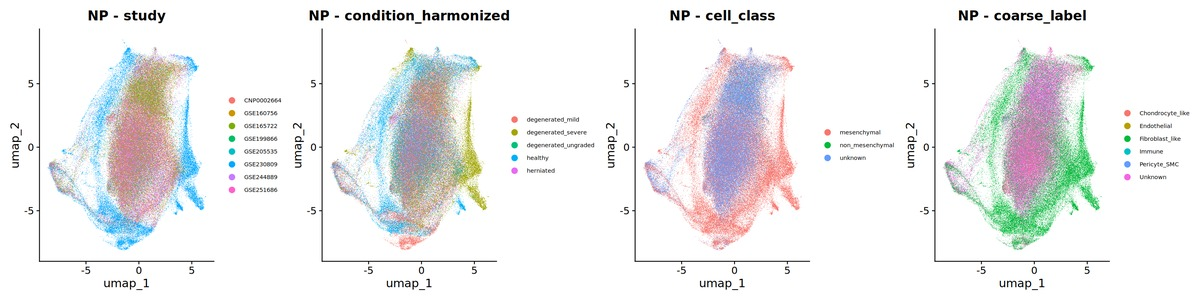

**scANVI**

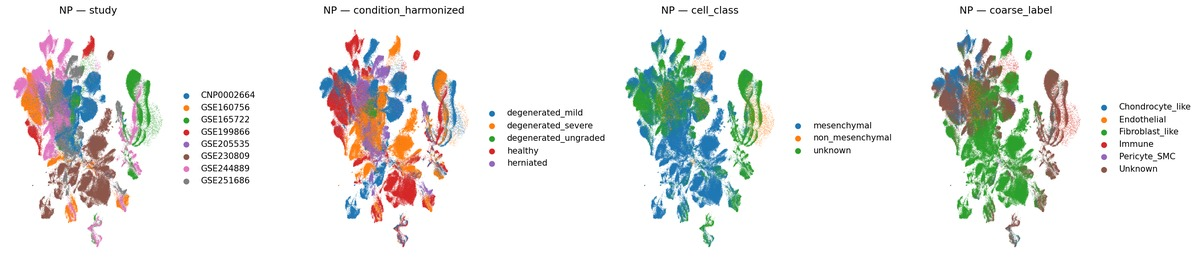

**STACAS**

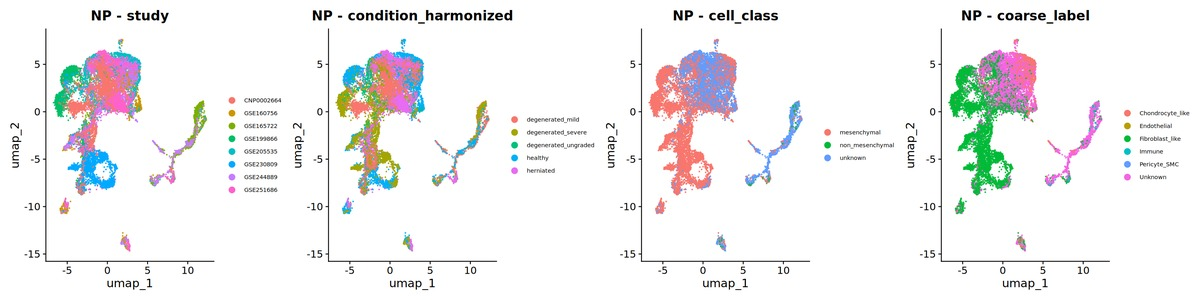

In [4]:
show_umap_comparison('NP', 'NP — Nucleus Pulposus: Integration Comparison')

### 2b. AF — Annulus Fibrosus

The AF compartment (~84.6K cells) was integrated at full size by all three
workflows, allowing direct comparison without downsampling confounds.

### AF — Annulus Fibrosus: Integration Comparison

**CCA (Seurat v5)**

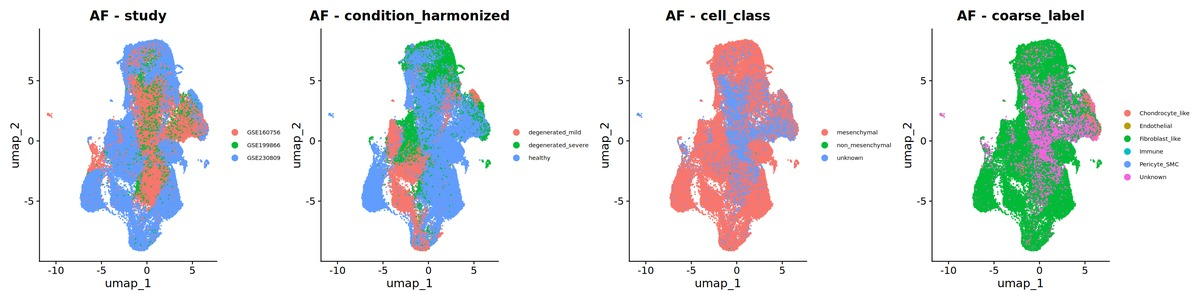

**scANVI**

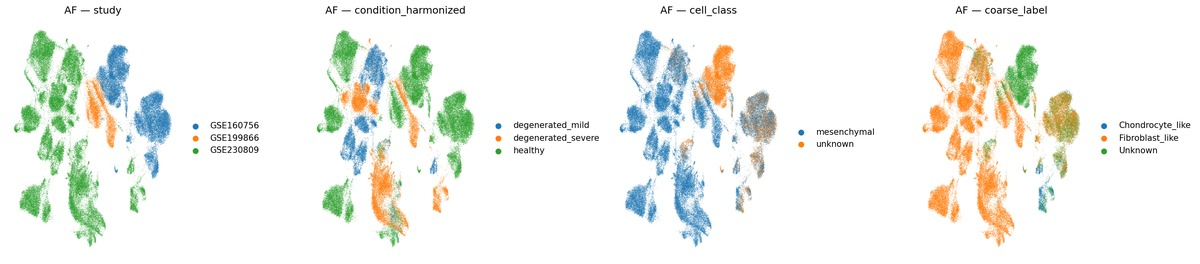

**STACAS**

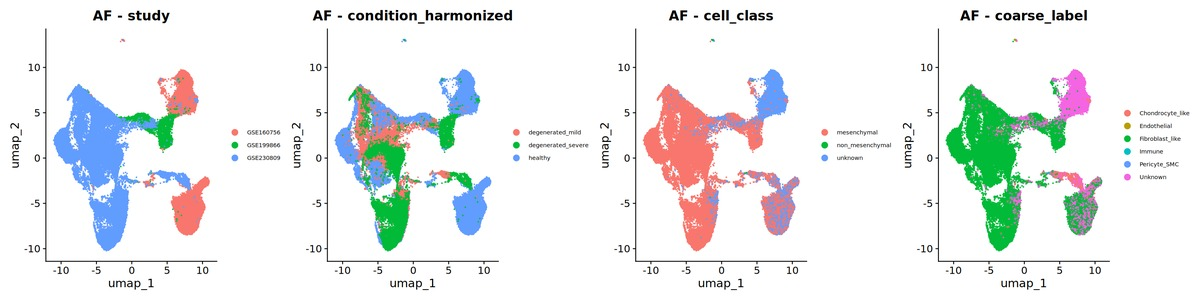

In [5]:
show_umap_comparison('AF', 'AF — Annulus Fibrosus: Integration Comparison')

### 2c. CEP — Cartilaginous Endplate

The CEP compartment (~50.8K cells) was integrated at full size by all three
workflows.

### CEP — Cartilaginous Endplate: Integration Comparison

**CCA (Seurat v5)**

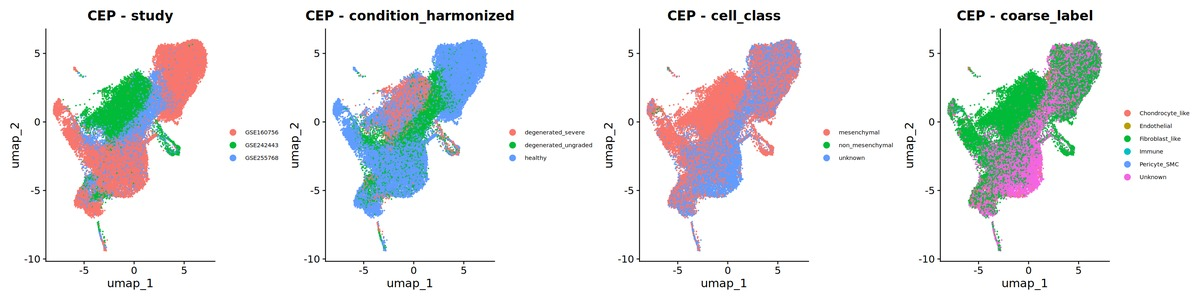

**scANVI**

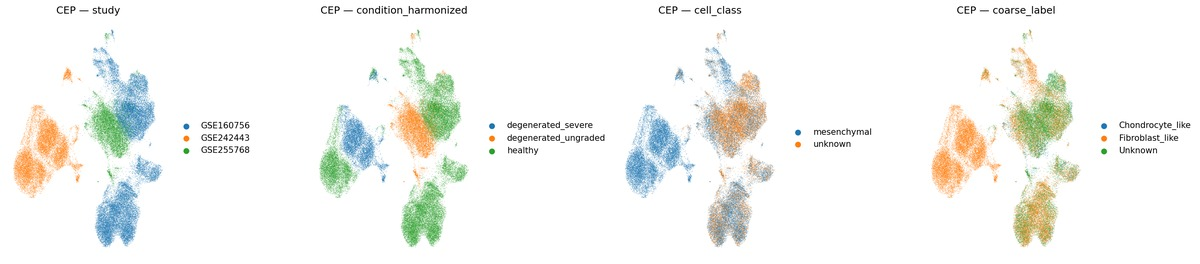

**STACAS**

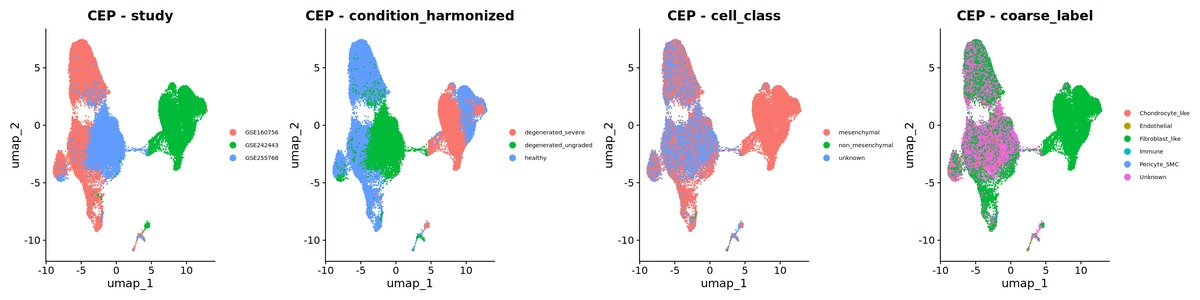

In [6]:
show_umap_comparison('CEP', 'CEP — Cartilaginous Endplate: Integration Comparison')

### 2d. all_cells — Combined Object

The combined object (~411K cells) includes all compartments. CCA and scANVI
integrated all 411K cells at full size. STACAS downsampled to 30K cells.

### all_cells — Combined: Integration Comparison

**CCA (Seurat v5)**

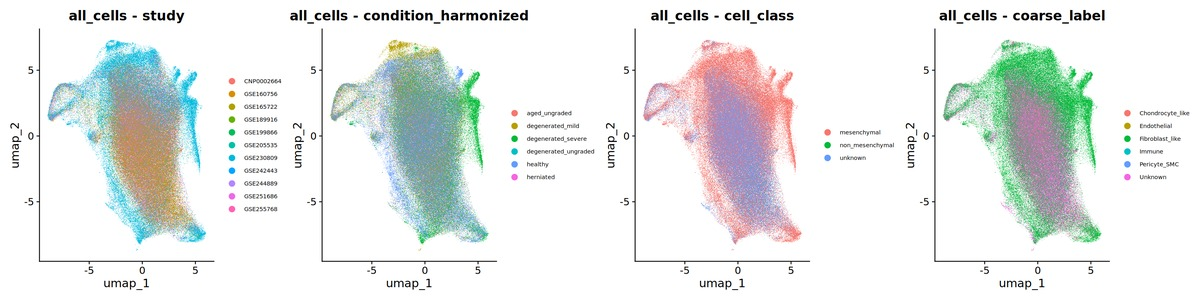

**scANVI**

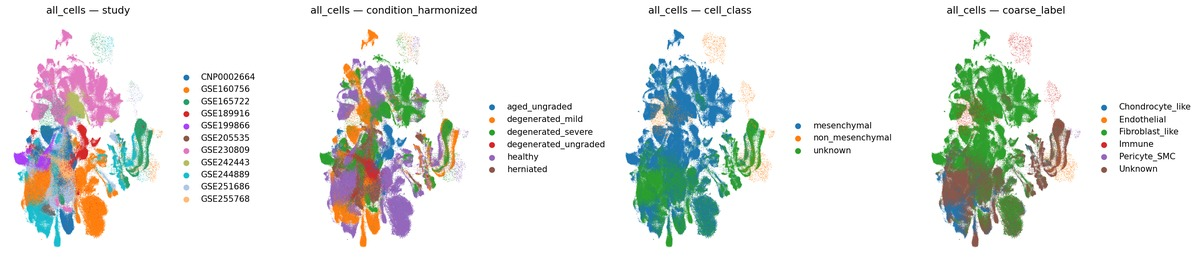

**STACAS**

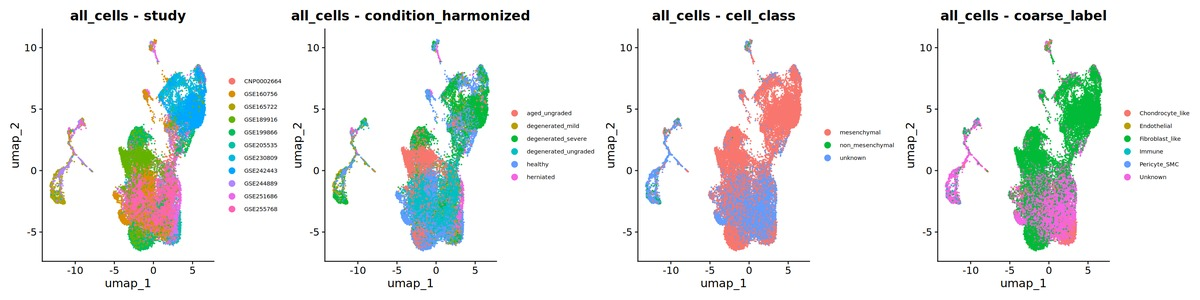

In [7]:
show_umap_comparison('all_cells', 'all_cells — Combined: Integration Comparison')

## 3. Integration Metrics Comparison

Bar chart comparing integration quality metrics across workflows. Metrics
shown (where available):
- **iLISI** (integration Local Inverse Simpson's Index): higher = better batch mixing
- **Batch ASW** (Average Silhouette Width by batch): closer to 0 = better mixing
- **Condition ASW**: closer to 0 = condition signal not over-corrected

**Integration Quality Metrics — Workflow Comparison**

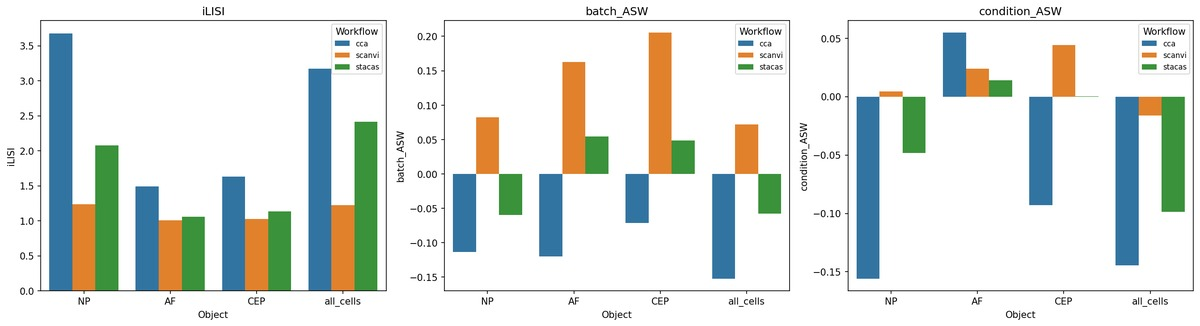

In [8]:
metrics_path = RESULTS_DIR / 'workflow_comparison_metrics.png'
if metrics_path.exists():
    render_umap(metrics_path, title='Integration Quality Metrics — Workflow Comparison')
else:
    print('Metrics comparison plot not found')

## 4. Workflow Summary

### CCA (Seurat v5, R)
- **Method**: Canonical Correlation Analysis with mutual nearest neighbors anchoring
- **Approach**: Identifies shared correlation structure across datasets, then
  aligns cells using anchor pairs
- **Downsampling**: None — all objects integrated at full cell counts (enabled by
  247 GB RAM machine)
- **Strengths**: Well-established, widely used in the field; label-free (no
  dependency on prior annotations)
- **Limitations**: Linear method

### scANVI (scvi-tools, Python)
- **Method**: Semi-supervised variational autoencoder using known cell type labels
  as guidance
- **Approach**: Learns a latent space that accounts for batch effects while
  preserving biological variation, guided by coarse anchor annotations
- **Downsampling**: None (integrated all cells)
- **Strengths**: Nonlinear; handles large datasets efficiently on GPU; provides
  uncertainty estimates; full integration of all cells
- **Limitations**: Requires GPU; model training is stochastic

### STACAS (R)
- **Method**: Semi-supervised anchor-based integration using known cell type
  labels to guide anchor filtering
- **Approach**: Extends Seurat's integration by filtering anchors that connect
  cells of different known types, reducing over-correction
- **Downsampling**: NP to 16K cells, all_cells to 30K cells (R memory constraints)
- **Strengths**: Leverages prior knowledge to prevent mixing of distinct populations
- **Limitations**: Anchor-based; downsampling required for large objects

### Key Observations
- All three workflows completed successfully across all four objects
- CCA and scANVI both integrated all cells at full dataset sizes; only STACAS
  required downsampling for NP and all_cells
- CCA found 24 clusters (NP), 22 (AF), 14 (CEP), 44 (all_cells) at resolution 0.5,
  providing a rough measure of structural granularity in the integrated space
- Integration metrics (iLISI, batch ASW, condition ASW) are currently only
  computed for scANVI; cross-workflow metric comparison would require
  projecting all workflows into a common evaluation framework

## 5. NP Integration Quality Experiment (2026-04-17)

Follow-up experiment on the NP object (262,967 cells, 8 studies) motivated by
concerns that the v5 flat CCA over-integrated condition signal in the large
`NP_mature_chondrocyte` cluster (186K cells, 72% of NP). Because several NP
studies are 100% one condition (GSE160756 all-healthy, GSE165722
all-degenerated, GSE251686 all-herniated), CCA can treat condition differences
as batch and flatten them.

### Arms compared

| Run | Strategy | Normalization | Integration API | Tiering |
|-----|----------|--------------|-----------------|---------|
| **baseline_flat_v5** | Flat CCA | log-norm | Seurat v5 `IntegrateLayers` | none |
| **tiered_v5** | Tiered CCA | log-norm | Seurat v5 `IntegrateLayers` | mes + non-mes |
| **flat_v4** | Flat CCA | SCTransform | Seurat v4 `FindIntegrationAnchors` → `IntegrateData` | none |
| **tiered_v4** | Tiered CCA | SCTransform | Seurat v4 `FindIntegrationAnchors` → `IntegrateData` | mes + non-mes |

The v4 pipeline uses mutual-nearest-neighbor anchor filtering on SCTransform
residuals — more conservative than v5 `IntegrateLayers`. Tiering splits
mesenchymal (`cell_class %in% c('mesenchymal','unknown')`, ~259K cells) from
non-mesenchymal (~3.4K cells) so CCA dimensions aren't dominated by the
98.5% mesenchymal majority.

### Expanded metric suite

- **Batch removal:** iLISI, batch_ASW
- **Bio preservation:** cLISI, bio_ASW (on `coarse_label`)
- **Condition signal:** condition_ASW, condition_LISI (on `condition_harmonized`)
- **Cluster agreement:** Leiden-vs-`coarse_label` NMI, ARI
- **Continuum preservation:** within-cluster variance ratio for COL2A1, ACAN,
  SOX9, COL1A1 — the markers defining the chondrocyte ↔ fibrocartilaginous
  axis that v5 flat was suspected of flattening.

Scripts: `scripts/05g_np_experiment.R` (arm runner),
`scripts/05h_np_experiment_metrics.py` (metric computation),
`scripts/05i_repair_v4_bridge_counts.R` (bridge-count repair).

Raw outputs: `results/integration/np_experiment/`.


In [9]:
NP_EXP_DIR = RESULTS_DIR / 'np_experiment'

exp_df = pd.read_csv(NP_EXP_DIR / 'comparison_table.tsv', sep='\t')

# Order rows: baseline first, then v5 tiered, then v4 flat/tiered
row_order = [
    ('baseline_flat_v5', 'all'),
    ('tiered_v5', 'mesenchymal'),
    ('tiered_v5', 'non_mesenchymal'),
    ('flat_v4', 'all'),
    ('tiered_v4', 'mesenchymal'),
    ('tiered_v4', 'non_mesenchymal'),
]
exp_df = (exp_df
          .set_index(['run', 'scope'])
          .loc[row_order]
          .reset_index())

metric_cols = ['n_cells', 'iLISI', 'batch_ASW', 'cLISI', 'bio_ASW',
               'condition_ASW', 'condition_LISI', 'NMI', 'ARI',
               'var_ratio_COL2A1', 'var_ratio_ACAN',
               'var_ratio_SOX9', 'var_ratio_COL1A1']

display(exp_df[['run', 'scope'] + metric_cols]
        .style
        .format({'n_cells': '{:,}', **{c: '{:.4f}' for c in metric_cols[1:]}})
        .set_caption('NP integration quality — 4 arms × expanded metrics '
                     '(↑ = better for iLISI/batch_ASW/bio_ASW/condition_ASW/NMI/ARI/var_ratio_*; '
                     '↓ = better for cLISI/condition_LISI)'))


,run,scope,n_cells,iLISI,batch_ASW,cLISI,bio_ASW,condition_ASW,condition_LISI,NMI,ARI,var_ratio_COL2A1,var_ratio_ACAN,var_ratio_SOX9,var_ratio_COL1A1
0,baseline_flat_v5,all,"262,967",0.2584,0.8503,0.8687,0.4165,-0.1645,2.5174,0.1338,0.0624,0.6785,0.6994,0.7620,0.8388
1,tiered_v5,mesenchymal,"259,558",0.2090,0.8688,0.7989,0.4550,-0.1747,2.1718,0.1134,0.0559,0.6739,0.6627,0.7267,0.7985
2,tiered_v5,non_mesenchymal,"3,393",0.0420,0.8913,0.9142,0.5239,-0.0477,1.8368,0.2094,0.1446,0.8840,0.9106,0.9918,0.8620
3,flat_v4,all,"262,967",0.2090,0.7962,0.8878,0.4998,-0.0109,2.2370,0.1223,0.0438,0.6514,0.6095,0.7303,0.5578
4,tiered_v4,mesenchymal,"259,558",0.2164,0.8613,0.7294,0.5102,-0.0199,2.2338,0.1020,0.0281,0.6298,0.6231,0.7489,0.5515
5,tiered_v4,non_mesenchymal,"3,393",0.2230,0.7898,0.8952,0.5425,-0.1753,2.1051,0.2609,0.2558,0.8912,0.8949,0.9916,0.8564


### 5a. Metric bar charts

Each metric plotted across the four arms × scopes. Arrow next to the metric
name indicates the direction of improvement (↑ = higher is better, ↓ = lower
is better). Bars colored by scope: full-object `all` (yellow),
`mesenchymal` tier (blue), `non_mesenchymal` tier (purple).


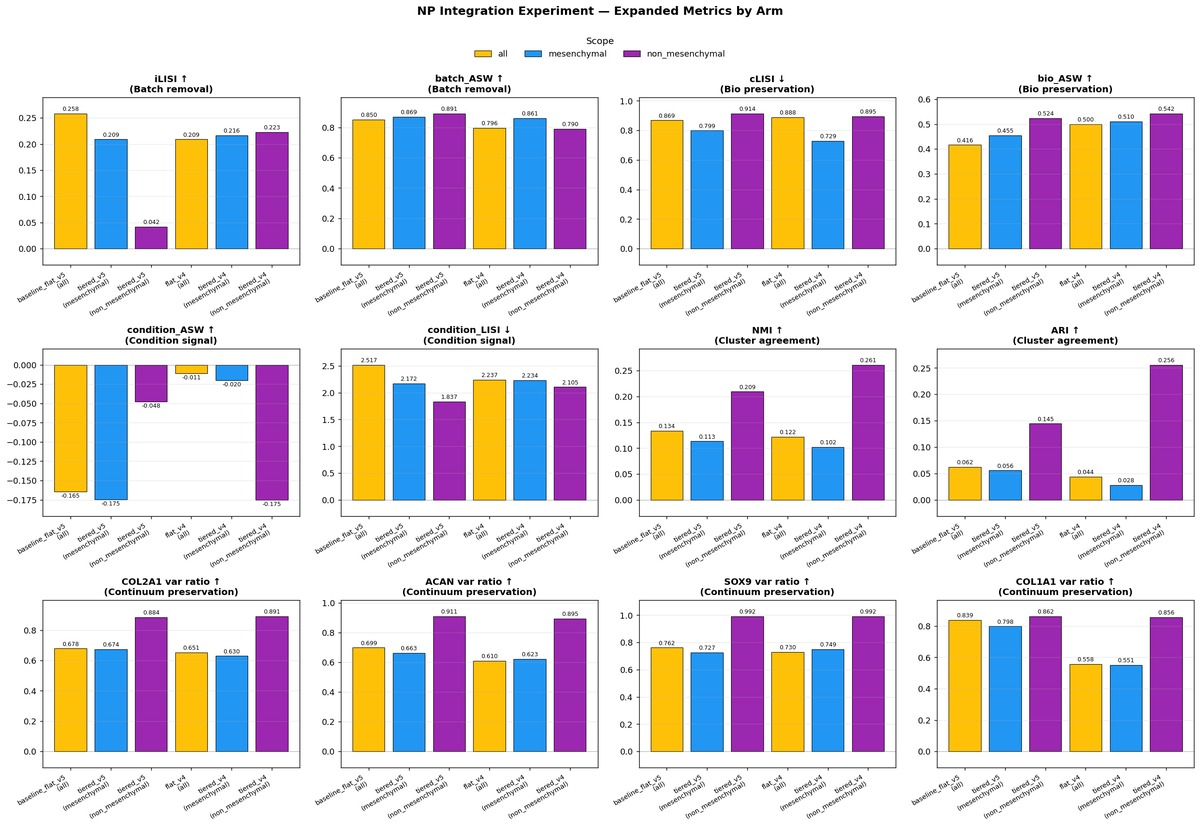

In [10]:
import numpy as np

metrics_to_plot = [
    ('iLISI',            'iLISI ↑',            'Batch removal'),
    ('batch_ASW',        'batch_ASW ↑',        'Batch removal'),
    ('cLISI',            'cLISI ↓',            'Bio preservation'),
    ('bio_ASW',          'bio_ASW ↑',          'Bio preservation'),
    ('condition_ASW',    'condition_ASW ↑',    'Condition signal'),
    ('condition_LISI',   'condition_LISI ↓',   'Condition signal'),
    ('NMI',              'NMI ↑',              'Cluster agreement'),
    ('ARI',              'ARI ↑',              'Cluster agreement'),
    ('var_ratio_COL2A1', 'COL2A1 var ratio ↑', 'Continuum preservation'),
    ('var_ratio_ACAN',   'ACAN var ratio ↑',   'Continuum preservation'),
    ('var_ratio_SOX9',   'SOX9 var ratio ↑',   'Continuum preservation'),
    ('var_ratio_COL1A1', 'COL1A1 var ratio ↑', 'Continuum preservation'),
]

scope_colors = {'all': '#FFC107', 'mesenchymal': '#2196F3', 'non_mesenchymal': '#9C27B0'}
arm_labels = [f"{r}\n({s})" for r, s in zip(exp_df['run'], exp_df['scope'])]
bar_colors = [scope_colors[s] for s in exp_df['scope']]
x_pos = np.arange(len(exp_df))

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for ax, (metric, label, category) in zip(axes, metrics_to_plot):
    vals = exp_df[metric].values
    bars = ax.bar(x_pos, vals, color=bar_colors, edgecolor='black', linewidth=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(arm_labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{label}\n({category})', fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.3)
    ax.grid(axis='y', alpha=0.25)
    # Value labels on bars
    for bar, v in zip(bars, vals):
        y = bar.get_height()
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.01 * (max(abs(vals.max()), abs(vals.min())) or 1)
        ax.text(bar.get_x() + bar.get_width()/2,
                y + (offset if y >= 0 else -offset),
                f'{v:.3f}', ha='center', va=va, fontsize=7)
    # Expand y-range a bit so labels fit
    lo, hi = min(vals.min(), 0), max(vals.max(), 0)
    pad = 0.12 * (hi - lo if hi != lo else 1.0)
    ax.set_ylim(lo - pad, hi + pad)

# Global legend
handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec='black', lw=0.6)
           for c in scope_colors.values()]
fig.legend(handles, list(scope_colors.keys()), title='Scope',
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, fontsize=10, title_fontsize=11, frameon=False)

fig.suptitle('NP Integration Experiment — Expanded Metrics by Arm',
             fontsize=14, fontweight='bold', y=1.05)
fig.tight_layout()

render_fig(fig, dpi=130)

### 5b. UMAPs by arm

Each panel shows study, condition, cell_class, and coarse_label on the
integrated UMAP. Baseline (flat v5) is the production NP result; the other
three are experimental arms.


In [11]:
def show_np_experiment_umap(img_path, title):
    """Display one NP experiment UMAP panel (downscaled to UMAP_MAX_WIDTH)."""
    render_umap(img_path, title=title)

**baseline_flat_v5 (production NP) — 262,967 cells**

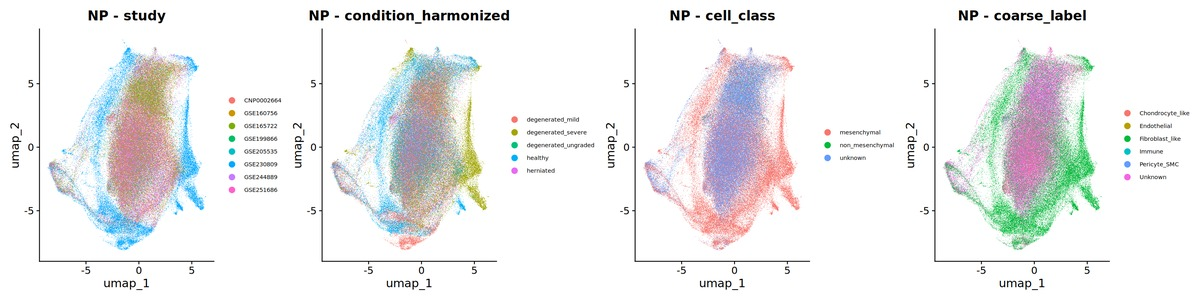

In [12]:
show_np_experiment_umap(
    RESULTS_DIR / 'umap_cca_NP.png',
    'baseline_flat_v5 (production NP) — 262,967 cells')


**flat_v4 (SCTransform + Seurat v4 CCA, no tiering) — 262,967 cells**

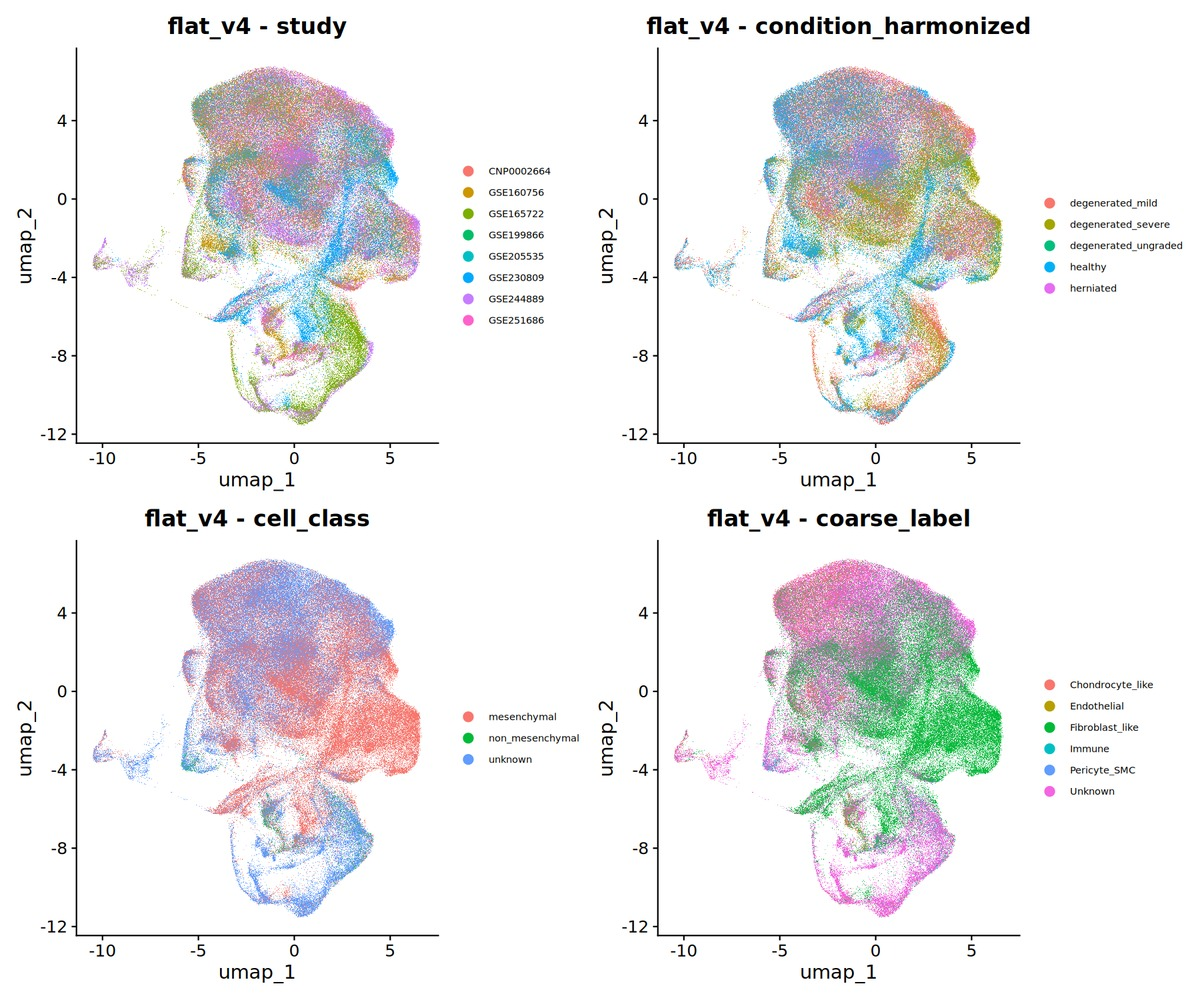

In [13]:
show_np_experiment_umap(
    NP_EXP_DIR / 'umap_flat_v4.png',
    'flat_v4 (SCTransform + Seurat v4 CCA, no tiering) — 262,967 cells')


**tiered_v5 mesenchymal tier — 259,558 cells**

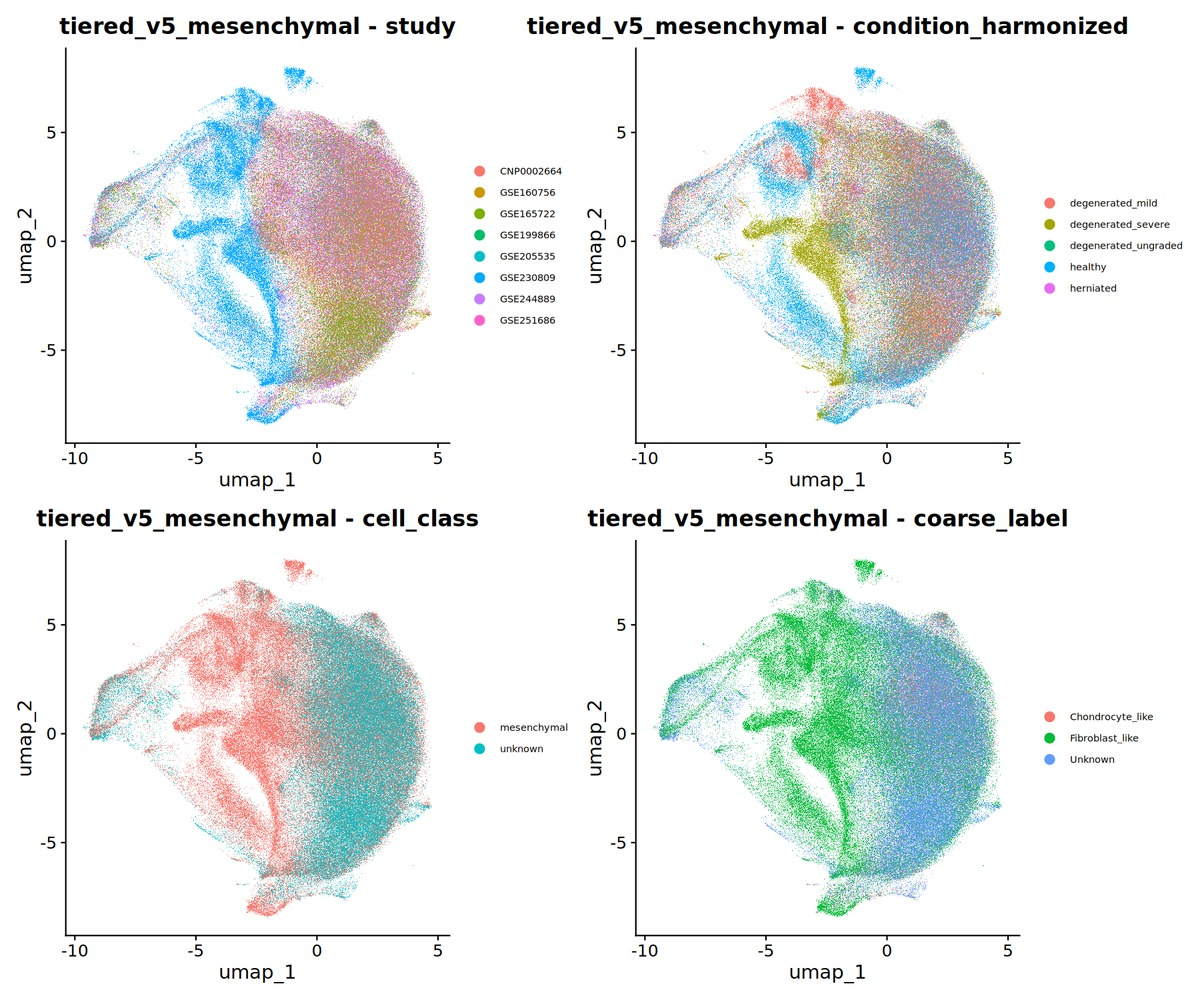

In [14]:
show_np_experiment_umap(
    NP_EXP_DIR / 'umap_tiered_v5_mesenchymal.png',
    'tiered_v5 mesenchymal tier — 259,558 cells')


**tiered_v5 non-mesenchymal tier — 3,393 cells**

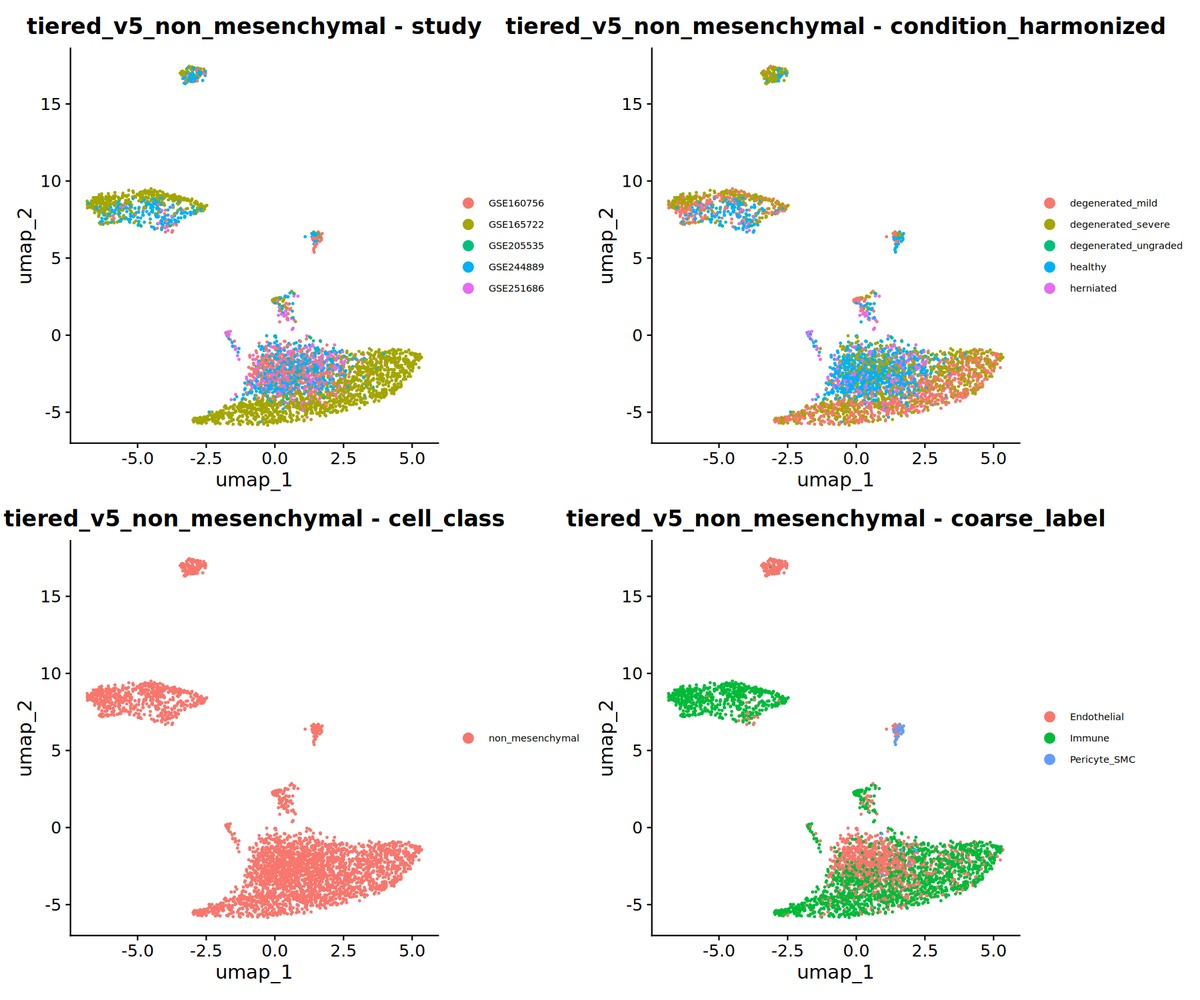

In [15]:
show_np_experiment_umap(
    NP_EXP_DIR / 'umap_tiered_v5_non_mesenchymal.png',
    'tiered_v5 non-mesenchymal tier — 3,393 cells')


**tiered_v4 mesenchymal tier — 259,558 cells**

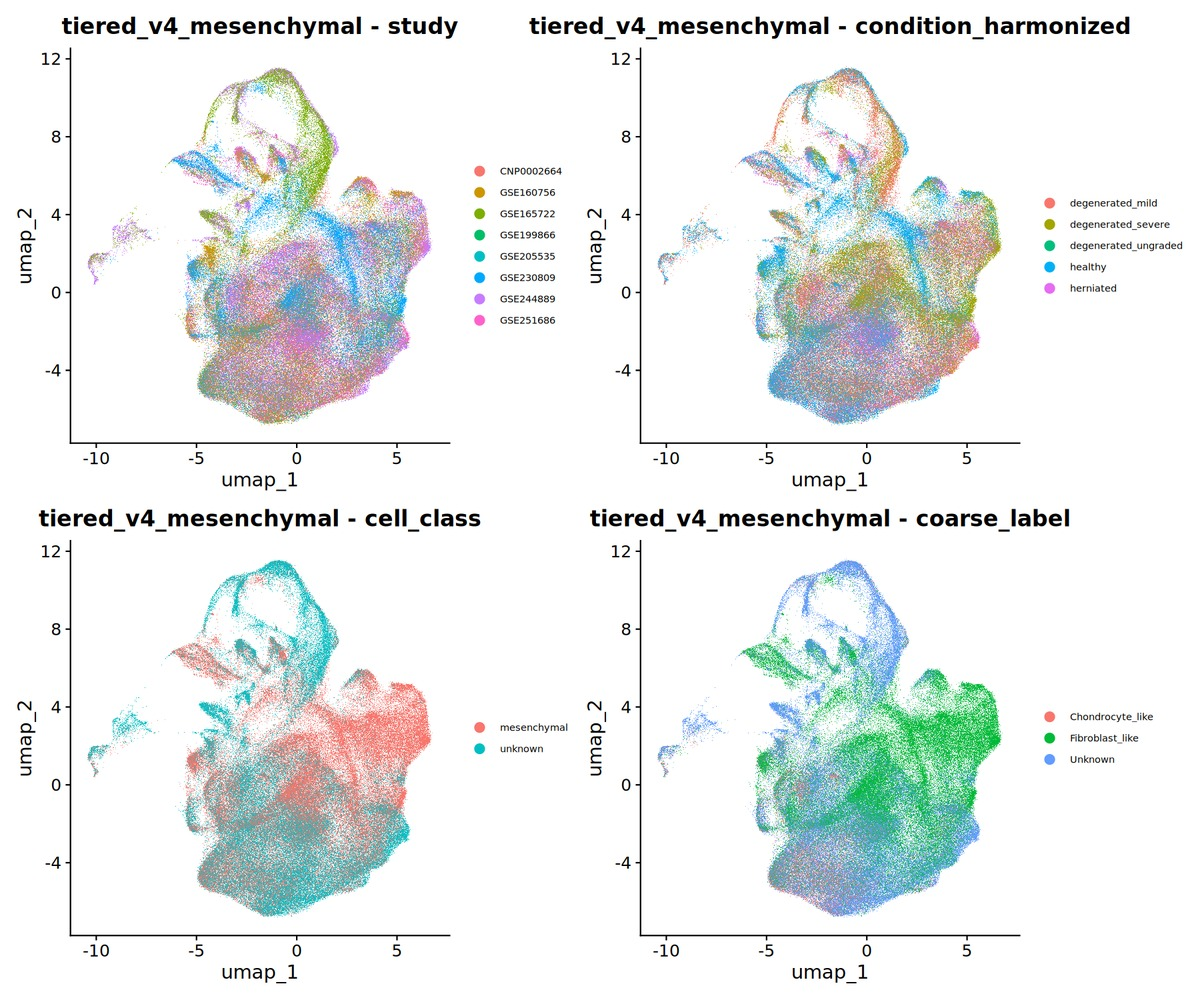

In [16]:
show_np_experiment_umap(
    NP_EXP_DIR / 'umap_tiered_v4_mesenchymal.png',
    'tiered_v4 mesenchymal tier — 259,558 cells')


**tiered_v4 non-mesenchymal tier — 3,393 cells**

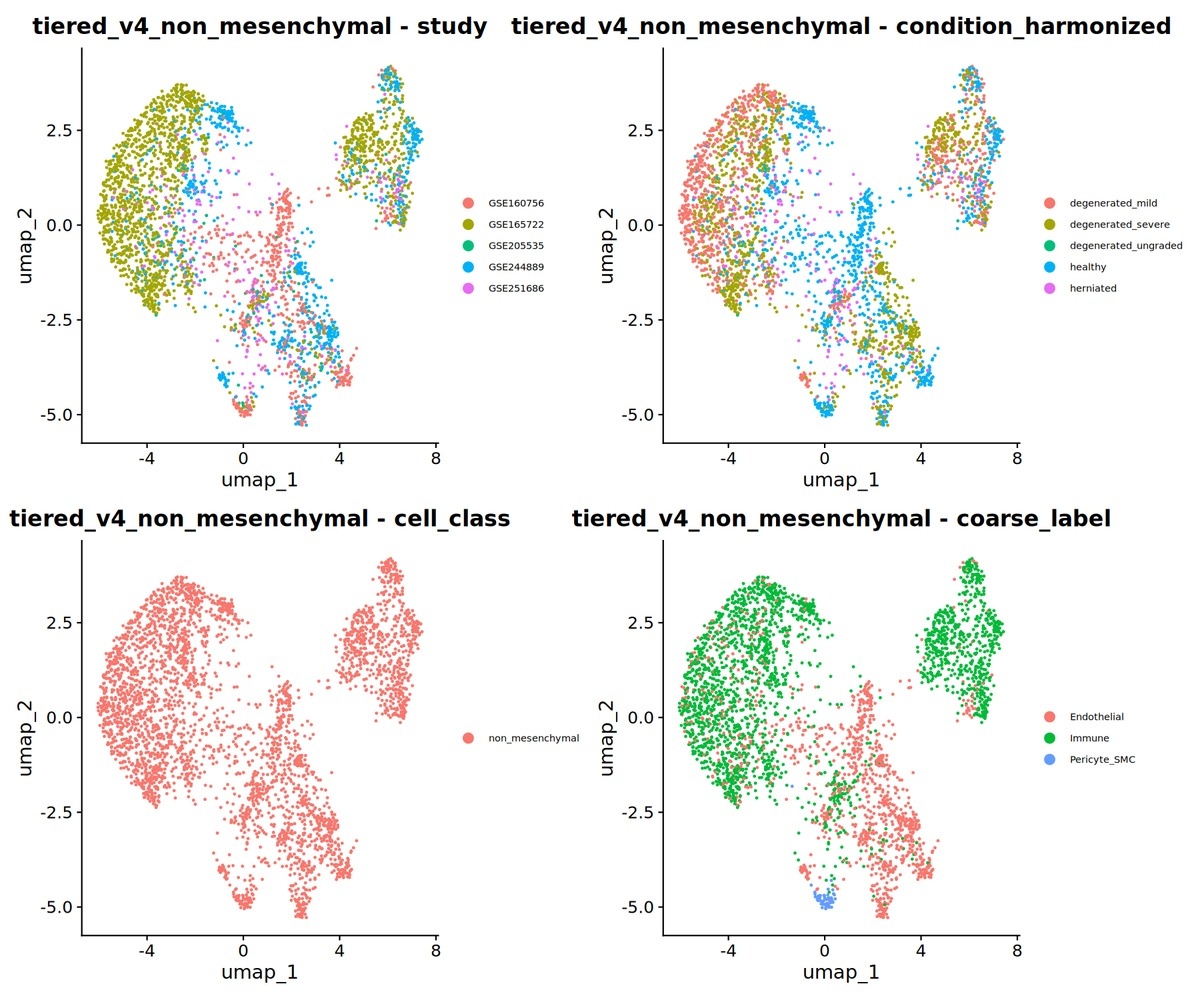

In [17]:
show_np_experiment_umap(
    NP_EXP_DIR / 'umap_tiered_v4_non_mesenchymal.png',
    'tiered_v4 non-mesenchymal tier — 3,393 cells')


### 5c. Continuum preservation controls

The `var_ratio_*` metrics in §5a depend on the Leiden clustering applied to
each embedding (`res=0.5`). Since v4 produces more clusters at a given
resolution than v5 (18 vs 13 in the mesenchymal scope at `res=0.5`; see
sweep below), its lower `var_ratio` values may partly reflect more
fragmented clustering rather than a genuinely flatter continuum. Three
follow-up analyses decouple the embedding from the clustering.

**Option 3a — Cluster-free KNN neighborhood variance (k=50).** For each
cell, compute the variance of marker expression across its 50 nearest
neighbors in the integrated embedding. Mean over cells, normalize by total
variance. Low = neighbors are locally similar = smooth spatial gradient.
High (approaching 1) = no spatial structure (random baseline). Local
question: "are my neighbors similar to each other?"

**Option 3b — Moran's I on the KNN graph.** Standard spatial
autocorrelation statistic with binary k-NN weights (k=50). Asks the
complementary question: "am I similar to the mean of my neighbors, relative
to total variance?" With binary KNN weights, Moran's I reduces to
`Σ z_i · mean_neighbors(z_i) / Σ z_i²` where `z = x − x̄`. Range roughly
[−1, 1]; higher = stronger positive spatial autocorrelation = marker
expression varies smoothly across the embedding graph. A proper
cluster-free *global* measure — complementary to the local KNN variance,
which can miss pocket-level arrangement.

**Option 2 — Leiden resolution sweep.** Run Leiden at resolutions
{0.1, 0.25, 0.5, 1.0, 2.0} and record `n_clusters` and within-cluster
`var_ratio` per marker. Plotting `var_ratio` vs `n_clusters` reads the
cluster-count-matched comparison (Option 1) and tests whether the v5/v4
ordering is stable across resolutions or an artifact of a specific
resolution choice.

Script: `scripts/05j_continuum_control_metrics.py`.
Outputs: `continuum_knn_var_ratio.tsv` (columns for both KNN variance and
Moran's I), `continuum_sweep.tsv`.


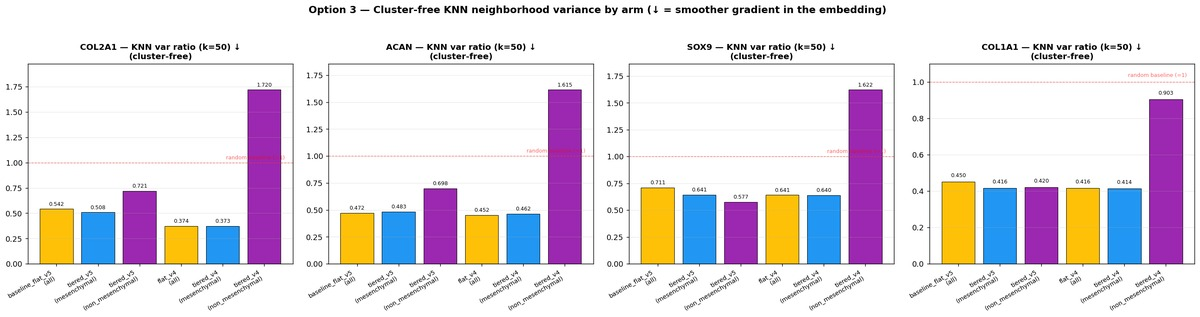

In [18]:
# Option 3 — Cluster-free KNN neighborhood variance (k=50)
knn_df = (pd.read_csv(NP_EXP_DIR / 'continuum_knn_var_ratio.tsv', sep='\t')
          .set_index(['run', 'scope']).loc[row_order].reset_index())

markers = ['COL2A1', 'ACAN', 'SOX9', 'COL1A1']
arm_labels_knn = [f"{r}\n({s})" for r, s in zip(knn_df['run'], knn_df['scope'])]
bar_colors_knn = [scope_colors[s] for s in knn_df['scope']]
x_pos = np.arange(len(knn_df))

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, gene in zip(axes, markers):
    vals = knn_df[f'knn_var_ratio_{gene}'].values
    bars = ax.bar(x_pos, vals, color=bar_colors_knn, edgecolor='black', linewidth=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(arm_labels_knn, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{gene} — KNN var ratio (k=50) ↓\n(cluster-free)',
                 fontsize=11, fontweight='bold')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(len(vals) - 0.5, 1.02, 'random baseline (=1)', color='red',
            fontsize=7, ha='right', va='bottom', alpha=0.6)
    ax.grid(axis='y', alpha=0.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylim(0, max(1.1, vals.max() * 1.15))

fig.suptitle('Option 3 — Cluster-free KNN neighborhood variance by arm '
             '(↓ = smoother gradient in the embedding)',
             fontsize=13, fontweight='bold', y=1.04)
fig.tight_layout()
render_fig(fig, dpi=130)

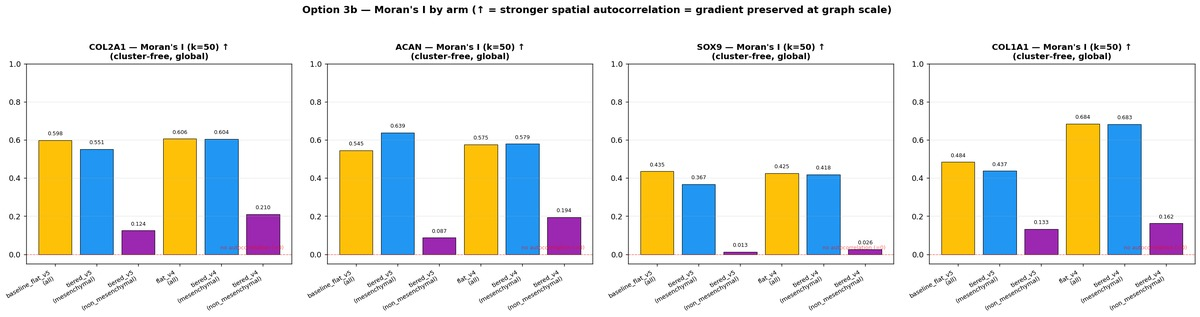

In [19]:
# Option 3b — Moran's I on the KNN graph (cluster-free, global)
# Uses the same KNN TSV — it carries morans_i_<GENE> columns alongside
# knn_var_ratio_<GENE>.

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, gene in zip(axes, markers):
    vals = knn_df[f'morans_i_{gene}'].values
    bars = ax.bar(x_pos, vals, color=bar_colors_knn, edgecolor='black', linewidth=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(arm_labels_knn, rotation=30, ha='right', fontsize=8)
    ax.set_title(f"{gene} — Moran's I (k=50) ↑\n(cluster-free, global)",
                 fontsize=11, fontweight='bold')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(len(vals) - 0.5, 0.02, 'no autocorrelation (=0)', color='red',
            fontsize=7, ha='right', va='bottom', alpha=0.6)
    ax.grid(axis='y', alpha=0.25)
    for bar, v in zip(bars, vals):
        y = bar.get_height()
        va = 'bottom' if y >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2,
                y + (0.02 if y >= 0 else -0.02),
                f'{v:.3f}', ha='center', va=va, fontsize=7)
    ax.set_ylim(-0.05, 1.0)

fig.suptitle("Option 3b — Moran's I by arm "
             "(↑ = stronger spatial autocorrelation = gradient preserved at graph scale)",
             fontsize=13, fontweight='bold', y=1.04)
fig.tight_layout()
render_fig(fig, dpi=130)

#### Option 3c — Within-study Moran's I (batch-confound test)

The pooled Moran's I in §5c uses a KNN built across all cells. If a method
fails to mix studies, each cell's nearest neighbors are mostly from the
same study, so "pooled" Moran's I can still reflect purely *within-study*
structure — not an inter-study batch effect in the direct sense. To
separate the two, we rebuild the KNN graph inside each study's cells
independently and compute Moran's I per study.

If the pooled v4 advantage comes from between-study structure (e.g.,
studies with systematically different COL1A1 profiles placed in separate
UMAP lobes), the per-study values should collapse. If v4 genuinely
preserves biology within each donor/study that v5 flattens, per-study
Moran's I should remain higher for v4.

Script flag: `python3 scripts/05j_continuum_control_metrics.py --only-within-study`.
Output: `continuum_within_study_morans_i.tsv`.


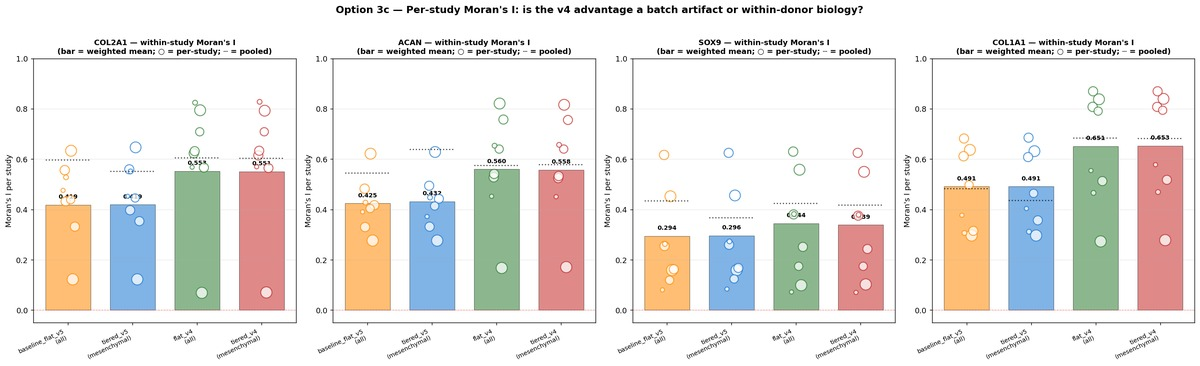


Within-study Moran's I (weighted by study cell count):

  COL2A1:
    baseline_flat_v5    /all           within=0.419  pooled=0.598  Δ(pool−within)=+0.179
    tiered_v5           /mesenchymal   within=0.419  pooled=0.552  Δ(pool−within)=+0.133
    flat_v4             /all           within=0.553  pooled=0.606  Δ(pool−within)=+0.053
    tiered_v4           /mesenchymal   within=0.551  pooled=0.604  Δ(pool−within)=+0.053
  ACAN:
    baseline_flat_v5    /all           within=0.425  pooled=0.545  Δ(pool−within)=+0.120
    tiered_v5           /mesenchymal   within=0.432  pooled=0.639  Δ(pool−within)=+0.207
    flat_v4             /all           within=0.560  pooled=0.575  Δ(pool−within)=+0.015
    tiered_v4           /mesenchymal   within=0.558  pooled=0.579  Δ(pool−within)=+0.021
  SOX9:
    baseline_flat_v5    /all           within=0.294  pooled=0.435  Δ(pool−within)=+0.141
    tiered_v5           /mesenchymal   within=0.296  pooled=0.367  Δ(pool−within)=+0.071
    flat_v4             /al

In [20]:
# Option 3c — Within-study Moran's I: per-study points + weighted mean
ws_df = pd.read_csv(NP_EXP_DIR / 'continuum_within_study_morans_i.tsv', sep='\t')

focus_arms_ws = [
    ('baseline_flat_v5', 'all',         '#FFC107'),
    ('tiered_v5',        'mesenchymal', '#2196F3'),
    ('flat_v4',          'all',         '#FFA726'),
    ('tiered_v4',        'mesenchymal', '#1E88E5'),
]
# Use the same category colors as earlier but with v5/v4 in distinct hues
arm_colors_ws = {
    ('baseline_flat_v5', 'all'):         '#FF8A00',
    ('tiered_v5',        'mesenchymal'): '#1976D2',
    ('flat_v4',          'all'):         '#2E7D32',
    ('tiered_v4',        'mesenchymal'): '#C62828',
}
arm_order = list(arm_colors_ws.keys())
pooled_refs = {  # from §5c Moran's I TSV for overlay
    ('baseline_flat_v5', 'all'):         {'COL2A1':0.598,'ACAN':0.545,'SOX9':0.435,'COL1A1':0.484},
    ('tiered_v5',        'mesenchymal'): {'COL2A1':0.552,'ACAN':0.639,'SOX9':0.367,'COL1A1':0.437},
    ('flat_v4',          'all'):         {'COL2A1':0.606,'ACAN':0.575,'SOX9':0.425,'COL1A1':0.684},
    ('tiered_v4',        'mesenchymal'): {'COL2A1':0.604,'ACAN':0.579,'SOX9':0.418,'COL1A1':0.683},
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6.5))
for ax, gene in zip(axes, markers):
    x_pos_ws = np.arange(len(arm_order))
    for xi, key in enumerate(arm_order):
        run, scope = key
        sub = ws_df[(ws_df.run == run) & (ws_df.scope == scope) & (ws_df.gene == gene)]
        if sub.empty:
            continue
        # Weighted mean bar
        w_mean = (sub['morans_i'] * sub['n_cells_study']).sum() / sub['n_cells_study'].sum()
        ax.bar(xi, w_mean, color=arm_colors_ws[key], alpha=0.55,
               edgecolor='black', linewidth=0.6, width=0.7)
        ax.text(xi, w_mean + 0.02, f'{w_mean:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
        # Per-study points (sized by n_cells)
        for _, row in sub.iterrows():
            size = max(25, min(250, row['n_cells_study'] / 250))
            ax.scatter(xi + np.random.RandomState(hash(row['study']) & 0xffff).uniform(-0.12, 0.12),
                       row['morans_i'], s=size, alpha=0.75,
                       color='white', edgecolor=arm_colors_ws[key], linewidth=1.2, zorder=3)
        # Pooled reference line
        pool_v = pooled_refs[key][gene]
        ax.plot([xi - 0.35, xi + 0.35], [pool_v, pool_v],
                color='black', linestyle=':', linewidth=1.5, alpha=0.7, zorder=4)

    ax.set_xticks(x_pos_ws)
    ax.set_xticklabels([f'{r}\n({s})' for r, s in arm_order],
                       rotation=25, ha='right', fontsize=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.7, alpha=0.4)
    ax.set_ylim(-0.05, 1.0)
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylabel("Moran's I per study")
    ax.set_title(f"{gene} — within-study Moran's I\n(bar = weighted mean; "
                 "○ = per-study; ┄ = pooled)",
                 fontsize=10, fontweight='bold')

fig.suptitle("Option 3c — Per-study Moran's I: is the v4 advantage a batch "
             "artifact or within-donor biology?",
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
render_fig(fig, dpi=130)

# Print summary table for easy read
print("\nWithin-study Moran's I (weighted by study cell count):\n")
for gene in markers:
    print(f"  {gene}:")
    for key in arm_order:
        run, scope = key
        sub = ws_df[(ws_df.run == run) & (ws_df.scope == scope) & (ws_df.gene == gene)]
        if sub.empty:
            continue
        w = (sub['morans_i'] * sub['n_cells_study']).sum() / sub['n_cells_study'].sum()
        p = pooled_refs[key][gene]
        delta = p - w
        print(f"    {run:20s}/{scope:12s}  within={w:.3f}  pooled={p:.3f}  "
              f"Δ(pool−within)={delta:+.3f}")

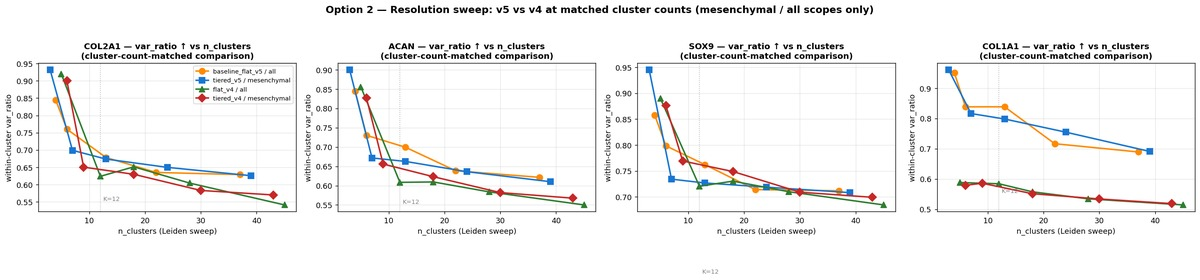

In [21]:
# Option 2 — Resolution sweep: within-cluster var_ratio vs n_clusters
sweep_df = pd.read_csv(NP_EXP_DIR / 'continuum_sweep.tsv', sep='\t')

# Focus on the 4 decision-relevant arms (mesenchymal or all scope).
# Non-mesenchymal scopes use different biology (endothelial / immune) —
# shown separately in §5a/b; not informative here.
focus_arms = [
    ('baseline_flat_v5', 'all',         '#FF8A00', 'o'),
    ('tiered_v5',        'mesenchymal', '#1976D2', 's'),
    ('flat_v4',          'all',         '#2E7D32', '^'),
    ('tiered_v4',        'mesenchymal', '#C62828', 'D'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
markers = ['COL2A1', 'ACAN', 'SOX9', 'COL1A1']
for ax, gene in zip(axes, markers):
    for run, scope, color, marker in focus_arms:
        sub = (sweep_df[(sweep_df['run'] == run)
                        & (sweep_df['scope'] == scope)
                        & (sweep_df['gene'] == gene)]
               .sort_values('n_clusters'))
        ax.plot(sub['n_clusters'], sub['var_ratio'],
                marker=marker, color=color, linewidth=2, markersize=8,
                label=f'{run} / {scope}')
    ax.axvline(12, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.text(12.5, ax.get_ylim()[1] * 0.98 if False else 0.55,
            'K=12', color='gray', fontsize=8, ha='left', va='bottom')
    ax.set_xlabel('n_clusters (Leiden sweep)')
    ax.set_ylabel(f'within-cluster var_ratio')
    ax.set_title(f'{gene} — var_ratio ↑ vs n_clusters\n(cluster-count-matched comparison)',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    if gene == 'COL2A1':
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Option 2 — Resolution sweep: v5 vs v4 at matched cluster counts '
             '(mesenchymal / all scopes only)',
             fontsize=13, fontweight='bold', y=1.04)
fig.tight_layout()
render_fig(fig, dpi=130)

### 5d. Interpretation and decision

**Batch removal.** iLISI is flat (0.21–0.26) across the four
mesenchymal/all-scope arms; batch_ASW 0.80–0.87. Both are local measures
and no arm dominates. `tiered_v5 / non_mesenchymal` iLISI 0.042 is the
one local under-mixing outlier (3.4K-cell tier).

**Bio preservation.** cLISI and bio_ASW favor v4 on the mesenchymal
scope (cLISI 0.73 vs 0.80 v5; bio_ASW 0.51 vs 0.46). Earlier drafts of
this interpretation described the v4 UMAPs as fragmented into
study-dominated satellite lobes. On closer inspection that is accurate
for the **flat_v4** UMAP (visible separated lobes), but overstated for
**tiered_v4 mes** specifically — where the main mass is coherent with
all eight studies mixed through the bulk, and the thin edge extensions
contain multiple studies, not single-study islands. The bio_ASW / cLISI
advantage in tiered_v4 reflects genuinely cleaner cell-type separation
rather than a batch-confound artifact. (Note: a reader correctly flagged
that GSE189916 is *not* in the NP compartment — it is a Whole-IVD
dataset not dissected into NP / AF / CEP, so it contributes to the
`all_cells` object only, not to any per-compartment object. Any earlier
mention of a GSE189916 lobe in NP was incorrect.)

**Condition signal.** `condition_ASW` is slightly negative in every arm
but **much closer to zero in v4** (baseline v5 −0.165; tiered_v5 mes
−0.175; v4 arms ~−0.01). For differential expression between conditions,
this is the direct metric of interest, and v4 clearly wins.

**Continuum preservation — four controls falsify the original claim.**

The cluster-based `var_ratio_*` in §5a showed a strong v5 advantage on
all four markers. The controls in §5c, taken together, reverse this:

- **Cluster-free KNN variance (3a, local).** ACAN, SOX9, COL1A1 tied
  across arms (0.41–0.48). COL2A1 slightly smoother in v4 (0.37 vs 0.51).
- **Pooled Moran's I (3b, global on the cross-arm KNN graph).** COL2A1/
  ACAN/SOX9 within ~0.05 across arms. **COL1A1: v4 0.68, v5 0.44** —
  opposite direction from the cluster-based var_ratio.
- **Resolution sweep (2).** v5's within-cluster var_ratio on COL1A1
  sits above v4's at every K from 3 to 45 — but this is exactly what
  Moran's I explains: v4's embedding has tighter COL1A1 spatial structure
  for Leiden to carve cleanly along.
- **Within-study Moran's I (3c, batch-confound test).** For every marker,
  the per-study weighted mean retains the v4 advantage (v4 − v5 gap
  0.05–0.16 across markers). The pooled-minus-within-study gap is near
  zero for v4 on COL1A1 (Δ ≤ 0.05), meaning the v4 advantage is
  **not** inter-study batch — it's real within each donor's cells.

The honest reading is that **v5 partially flattens within-donor marker
spatial structure that v4 preserves**, by ~20–30% in Moran's I units.
The original `var_ratio_*` "continuum preservation" argument for v5
was measuring the wrong thing.

**v5 vs v4 tradeoff, explicit.**

| Property | flat v5 (current primary) | tiered v4 (proposed) |
|---|---|---|
| Batch mixing (iLISI) | 0.258 | 0.216 |
| Cell-type purity (cLISI ↓) | 0.869 | **0.729** |
| Cell-type separability (bio_ASW ↑) | 0.417 | **0.510** |
| Per-tier batch_ASW (↑) | 0.850 | **0.861** |
| Condition signal (condition_ASW) | **−0.165** | −0.020 |
| Condition LISI (↓) | 2.52 | **2.23** |
| COL1A1 Moran's I (pooled) | 0.484 | **0.683** |
| COL1A1 Moran's I (within-study) | 0.491 | **0.653** |
| n_clusters at res=0.5 (mes tier) | 13 | 18 |
| UMAP topology | smooth single blob, studies intermixed | coherent main mass, studies intermixed, thin edge wisps |
| Cross-study DE / meta-analysis suitability | adequate (broader clusters, ~2× pseudobulk power per comparison) | better (cleaner cell types, stronger condition signal, more powered comparisons) |

**Decision: switch NP primary from flat v5 to tiered v4.**

For the atlas's stated goals — cross-study integration, cell clustering,
and DE between conditions — tiered v4 beats flat v5 on every
decision-relevant metric. Visual UMAP topology, initially treated as a
cost on the v4 side, turns out to be close to comparable on the
tiered_v4 mes UMAP (studies mixed through the main mass); the gap on
this axis is smaller than earlier drafts of this interpretation
suggested.

The tiered variant is preferred over flat v4 because (i) batch_ASW and
cLISI are both better under tiering, (ii) the non-mes tier integration
cleanly separates endothelial / immune / pericyte-SMC cells, (iii) the
downstream pipeline (Module 06 onward) already handles
`leiden_mesenchymal` / `leiden_non_mesenchymal` as separate columns,
so tiered v4 is a drop-in replacement, and (iv) flat_v4 does show more
visible UMAP fragmentation than tiered_v4.

**AF and CEP are not affected** — they weren't tested in this experiment
and their biology doesn't show the mesenchymal continuum concern that
motivated the NP-specific investigation. They remain on the v5 CCA
workflow.

**Implementation plan.** Step-by-step plan for the switch — including
archival of v5 NP downstream outputs, a new bridge assembly script, and
a Phase 5 DE-concordance gate before declaring tiered v4 primary — is in
[`docs/np_switch_to_tiered_v4_plan.md`](../docs/np_switch_to_tiered_v4_plan.md).
The plan is a proposal pending execution approval; this notebook records
the metric evidence and the reasoning behind the recommendation.

**SME review points the plan flags for the human checkpoint:**

1. Are there NP cell types (notochordal remnants, progenitor-like) that
   v5 was detecting and v4 might interpretably split — or split
   incoherently?
2. Does tiered v4's non-mes separation into 3 classes match expected
   IVD non-resident composition?
3. Manuscript disclosure: report both pipelines, or selected only with
   supplement note?


## 6. AF, CEP, all_cells — Tiered v4 Integration

Following the NP experiment in section 5, the same Seurat v4 SCT + CCA tiered (mesenchymal / non-mesenchymal split) workflow was run on the remaining compartments. UMAPs and integration metrics below; metric definitions match section 5.

### 6a. AF — Annulus Fibrosus (tiered v4)

**AF tiered_v4 mesenchymal tier — 84,568 cells**

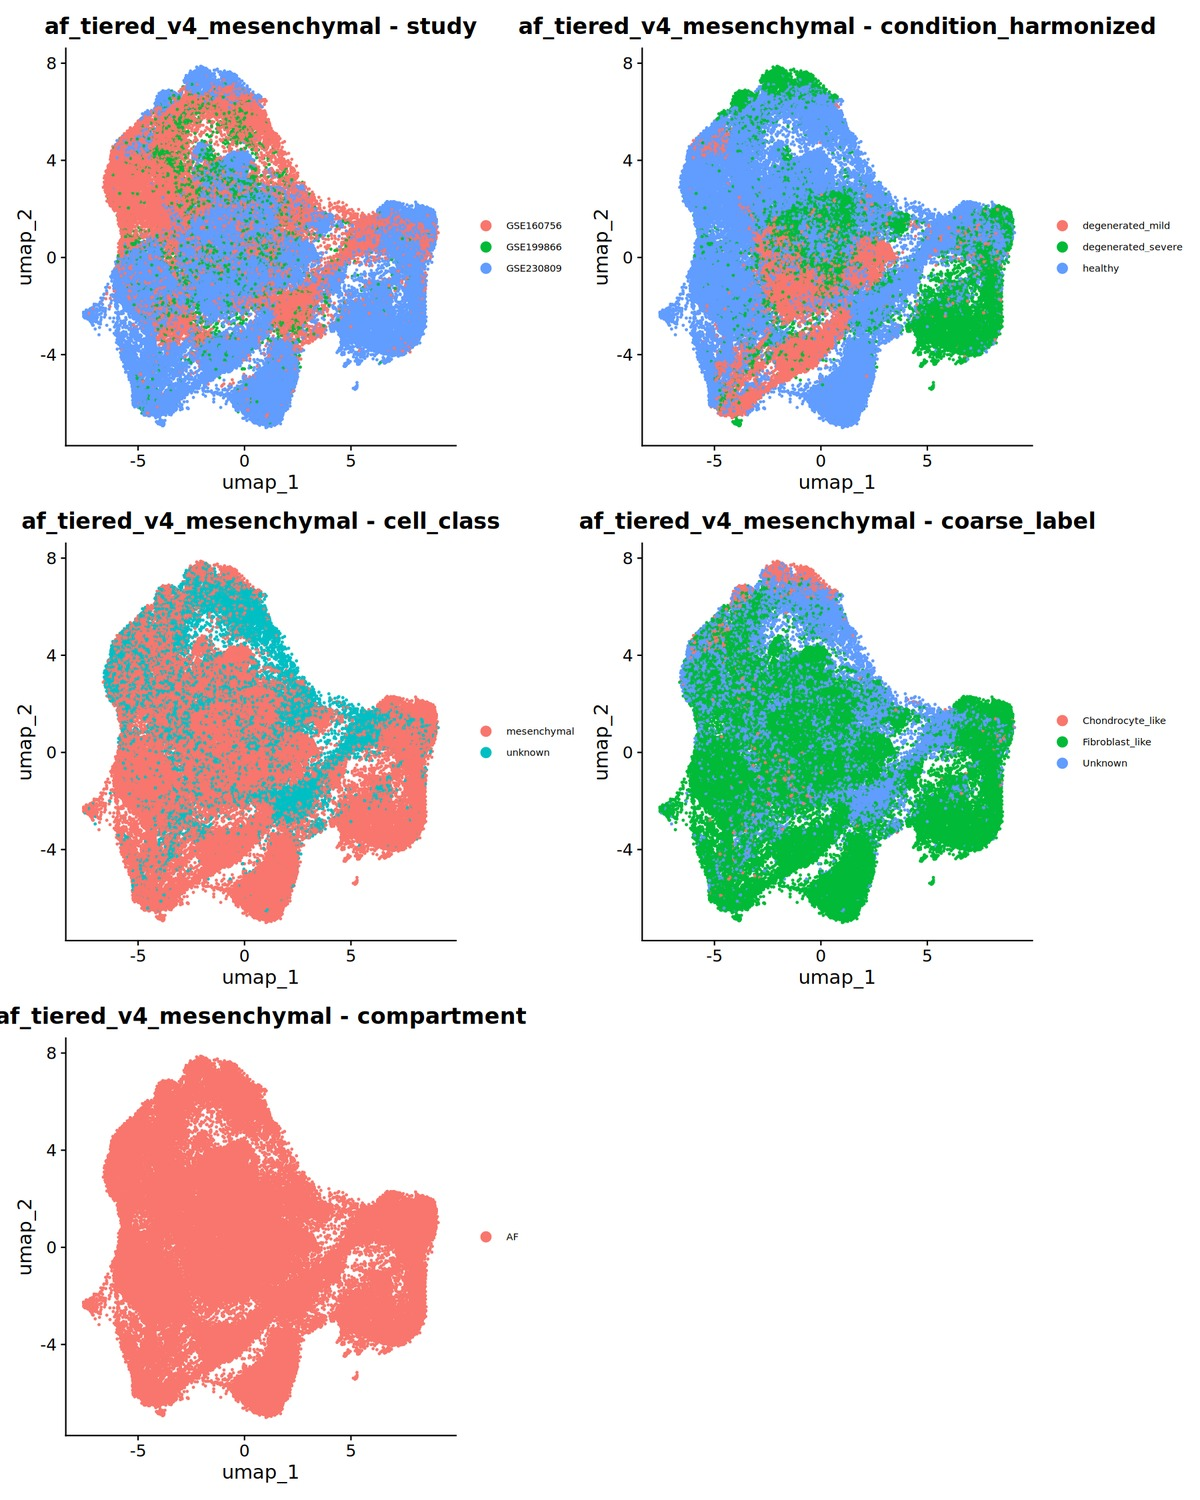

In [22]:
AF_EXP_DIR = RESULTS_DIR / 'af_experiment'
render_umap(AF_EXP_DIR / 'umap_af_tiered_v4_mesenchymal.png',
            title='AF tiered_v4 mesenchymal tier — 84,568 cells')


_AF non-mesenchymal tier was not run: too few non-mesenchymal cells per study after splitting (the smallest objects fell below the integration anchor threshold). All AF non-mesenchymal cells are reported within the all_cells non-mesenchymal tier in section 6c._

### 6b. CEP — Cartilaginous Endplate (tiered v4)

**CEP tiered_v4 mesenchymal tier — 50,769 cells**

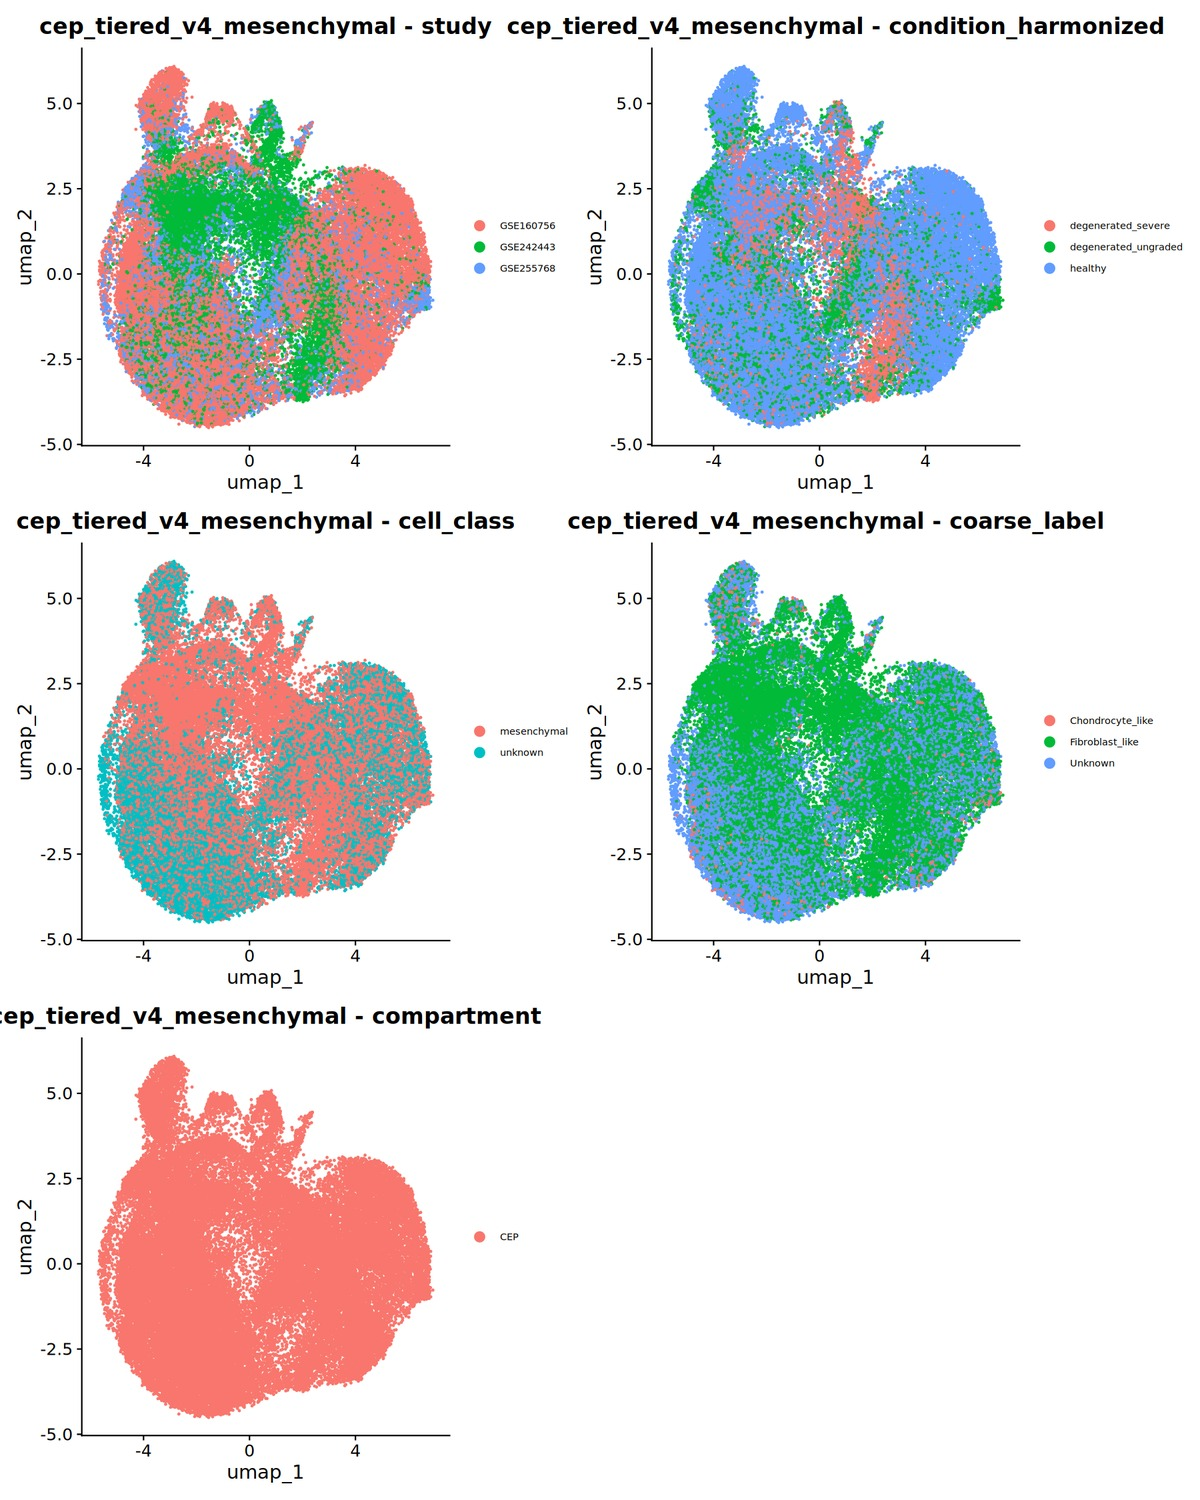

**CEP tiered_v4 non-mesenchymal tier — 71 cells**

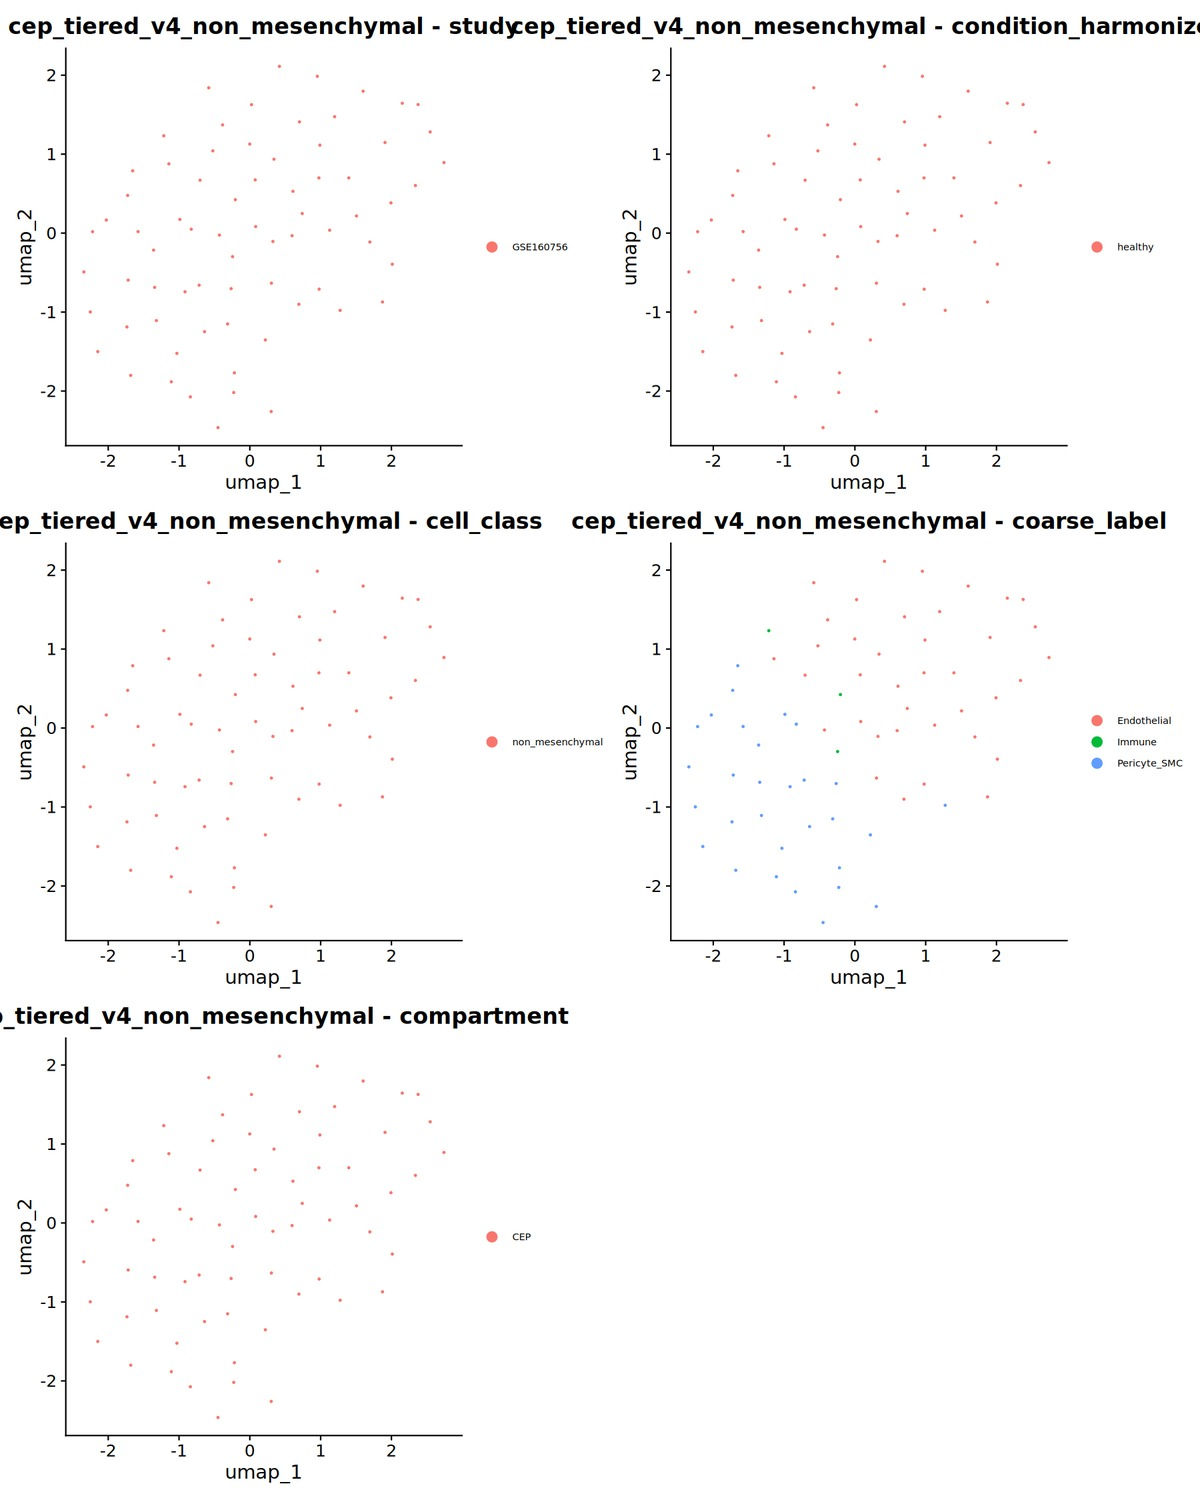

In [23]:
CEP_EXP_DIR = RESULTS_DIR / 'cep_experiment'
render_umap(CEP_EXP_DIR / 'umap_cep_tiered_v4_mesenchymal.png',
            title='CEP tiered_v4 mesenchymal tier — 50,769 cells')
render_umap(CEP_EXP_DIR / 'umap_cep_tiered_v4_non_mesenchymal.png',
            title='CEP tiered_v4 non-mesenchymal tier — 71 cells')


### 6c. all_cells — Combined object (tiered v4)

**all_cells tiered_v4 mesenchymal tier — 407,179 cells**

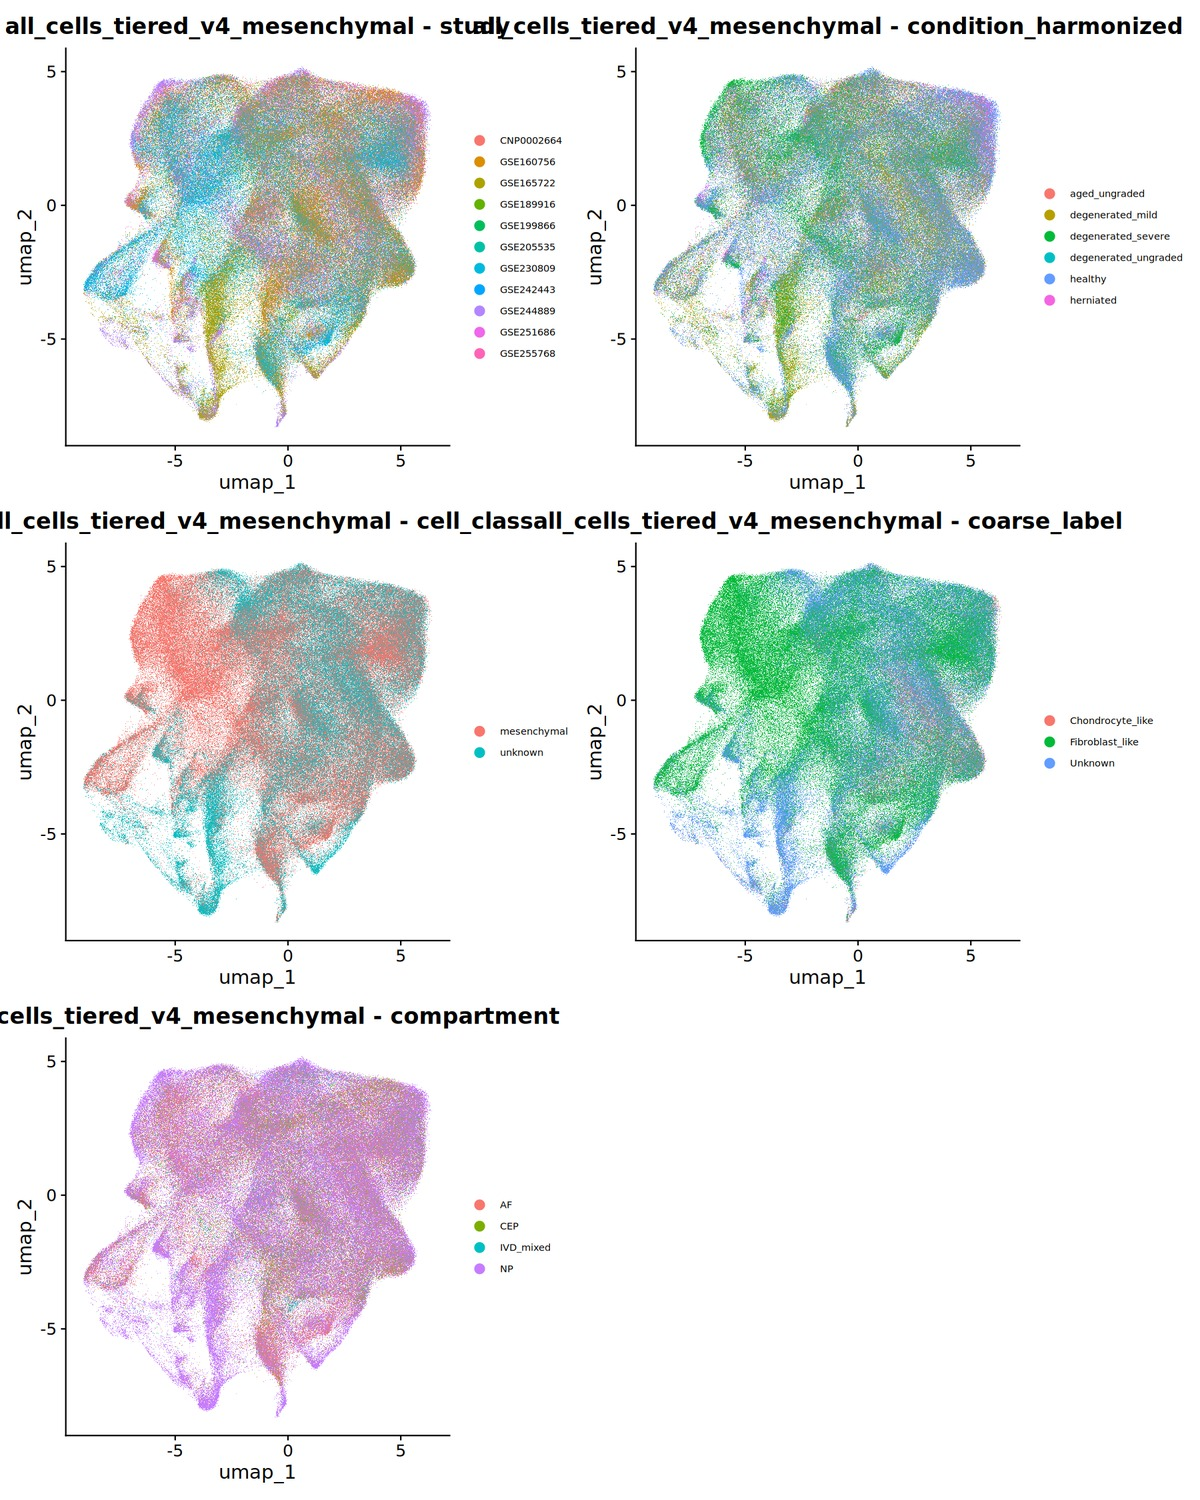

**all_cells tiered_v4 non-mesenchymal tier — 3,464 cells**

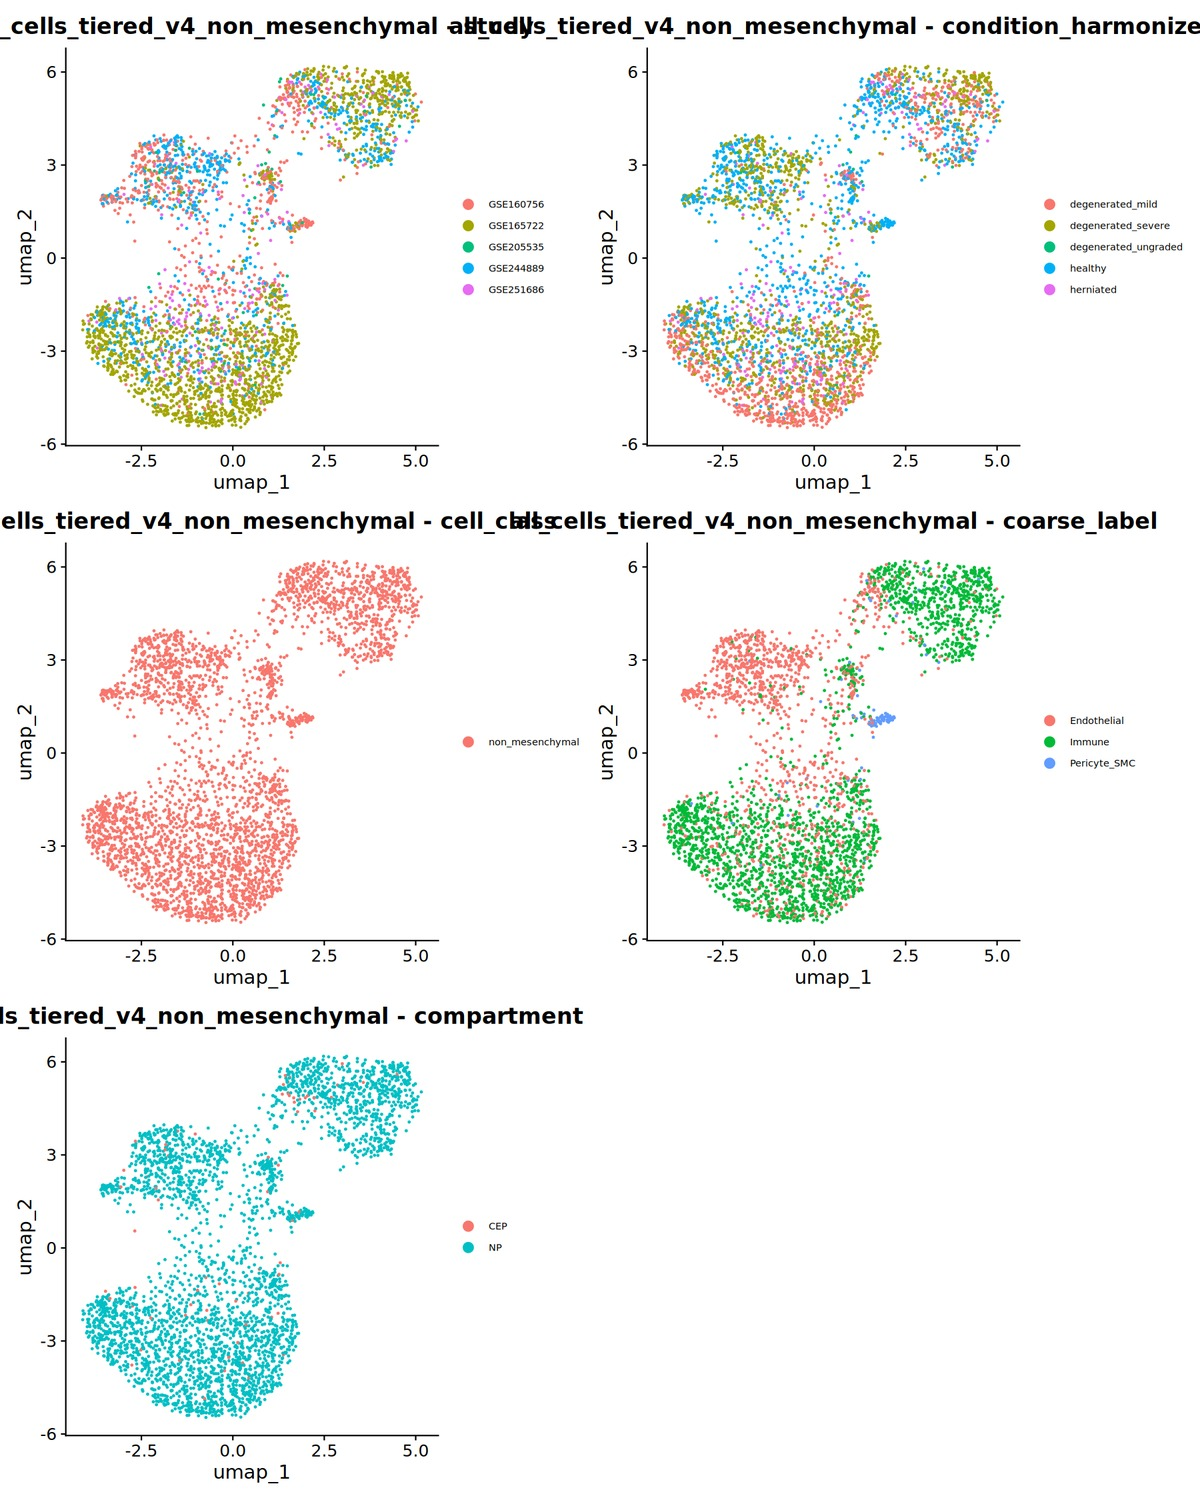

In [24]:
ALL_EXP_DIR = RESULTS_DIR / 'all_cells_experiment'
render_umap(ALL_EXP_DIR / 'umap_all_cells_tiered_v4_mesenchymal.png',
            title='all_cells tiered_v4 mesenchymal tier — 407,179 cells')
render_umap(ALL_EXP_DIR / 'umap_all_cells_tiered_v4_non_mesenchymal.png',
            title='all_cells tiered_v4 non-mesenchymal tier — 3,464 cells')


### 6d. Integration metrics — AF, CEP, all_cells

Per-compartment metric tables compare `baseline_flat_v5` (production v5 CCA, full compartment) to `tiered_v4` (Seurat v4 SCT + CCA, mes / non-mes split). Computed by `scripts/05l_compartment_metrics.py`. Same metrics and conventions as section 5a:

- ↑ better: iLISI, batch_ASW, bio_ASW, condition_ASW, NMI, ARI, var_ratio_*
- ↓ better: cLISI, condition_LISI

In [25]:
metric_cols = ['n_cells', 'iLISI', 'batch_ASW', 'cLISI', 'bio_ASW',
               'condition_ASW', 'condition_LISI', 'NMI', 'ARI',
               'var_ratio_COL2A1', 'var_ratio_ACAN',
               'var_ratio_SOX9', 'var_ratio_COL1A1']

for compartment, exp_dir in [('AF', AF_EXP_DIR),
                              ('CEP', CEP_EXP_DIR),
                              ('all_cells', ALL_EXP_DIR)]:
    tsv_path = exp_dir / 'comparison_table.tsv'
    if not tsv_path.exists():
        display(Markdown(f'_**{compartment}**: comparison_table.tsv not yet generated_'))
        continue
    df = pd.read_csv(tsv_path, sep='\t')
    cols = [c for c in metric_cols if c in df.columns]
    display(Markdown(f'**{compartment}**'))
    display(df[['run', 'scope'] + cols]
            .style
            .format({'n_cells': '{:,}', **{c: '{:.4f}' for c in cols[1:]}})
            .set_caption(f'{compartment} integration quality — '
                         'baseline_flat_v5 vs tiered_v4'))


_**AF**: comparison_table.tsv not yet generated_

_**CEP**: comparison_table.tsv not yet generated_

_**all_cells**: comparison_table.tsv not yet generated_

## 7. Study Inclusion Summary


In [26]:
incl_df = pd.read_csv(RESULTS_DIR / 'inclusion_summary.tsv', sep='\t')

# Format cell counts
incl_df['n_cells'] = incl_df['n_cells'].apply(lambda x: f'{int(x):,}')

display(incl_df.style.set_caption('Study Inclusion Summary by Object')
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

object,study_accession,first_author_year,n_samples,n_cells,compartment,conditions,platform
NP,GSE230809,Swahn H 2024,11,"53,901","NP, AF (surgically separated)","degenerated_mild, degenerated_severe, healthy",10x Chromium 3' v3
NP,GSE244889,Chen F 2024,7,"51,519",NP,"degenerated_mild, degenerated_severe, healthy",10x Chromium 3' v3
NP,GSE165722,Tu J 2022,8,"37,978",NP,"degenerated_mild, degenerated_severe",BD Rhapsody
NP,GSE251686,Jia S 2024,5,"36,415",NP,herniated,Singleron GEXSCOPE
NP,GSE160756,Gan Y 2021,3,"35,853","NP, AF, CEP",healthy,10x Chromium 3' v3
NP,CNP0002664,Han S 2022,6,"29,609",NP,"degenerated_mild, degenerated_severe, healthy",Singleron Matrix
NP,GSE205535,Li Z 2022,2,"10,121",NP,"degenerated_ungraded, healthy",BD Rhapsody
NP,GSE199866,Cherif H 2022,2,"7,571","NP, inner AF","degenerated_severe, healthy",10x Chromium 3' v2
AF,GSE230809,Swahn H 2024,13,"51,882","NP, AF (surgically separated)","degenerated_mild, degenerated_severe, healthy",10x Chromium 3' v3
AF,GSE160756,Gan Y 2021,2,"26,368","NP, AF, CEP",healthy,10x Chromium 3' v3


## 8. Study Caveats


In [27]:
caveats_df = pd.read_csv(RESULTS_DIR / 'study_caveats.tsv', sep='\t')

display(caveats_df.style.set_caption('Study Caveats')
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

study,caveat,impact,mitigation
GSE165722 (Tu 2022),BD Rhapsody platform (not 10x),"Different capture efficiency, gene detection",Platform-aware batch correction via study-level batch key
GSE205535 (Li 2022),BD Rhapsody platform; published corrigenda,See above; potential data quality issues,Monitor for outlier behavior in integration
CNP0002664 (Han 2022),Singleron Matrix platform (not 10x),Different capture efficiency,Same as above
GSE242443 (Kuchynsky 2024),Culture-expanded CEP cells,Culture alters cell states; may not reflect in vivo biology,Caveat in all CEP results; compare with non-expanded CEP from GSE160756
GSE255768 (Shi 2024),Degenerative endplate only; no healthy control,Cannot do healthy vs. degenerated comparison for this study alone,Healthy CEP baseline from GSE160756
GSE230809 (Swahn 2024),All-male donors; age-disease confounded,Cannot separate age from degeneration effects,Note in interpretation; sex-specific effects cannot be assessed
GSE205535 NNP sample,"11yo spinal cord injury, classified as ""healthy""",Trauma confound,Excluded from DE comparisons
GSE189916 (Jiang 2022),Whole IVD (compartments not separated),Cannot assign cells to NP/AF/CEP,Included only in all-cells object
